In [1]:
import os
import cv2
import torch
import random
import shutil
from tqdm import tqdm
from torchvision import transforms
import pandas as pd

import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from torch.utils.data import Dataset
from glob import glob

# vision
!pip install torchviz
from torchviz import make_dot


# weights
from torchvision.models import ResNet50_Weights
from torchvision.models import ResNet18_Weights
from torchvision.models import DenseNet121_Weights
from torchvision.models import VGG19_BN_Weights

In [11]:
# -----------------------------
# CONFIGURATION
# -----------------------------
DATASET_ROOT = "/kaggle/input/ucf101-action-recognition/"
OUTPUT_ROOT = "./UCF101/processed_data"

SELECTED_CLASSES = ["PlayingTabla","PommelHorse","JumpingJack","PushUps","PoleVault","HorseRace","HighJump","Drumming","HorseRiding","Diving","BreastStroke",
              "TrampolineJumping","YoYo","SalsaSpin","WalkingWithDog","VolleyballSpiking","ThrowDiscus","TennisSwing","TaiChi","Swing",
              "SoccerJuggling","Skijet","Skiing","SkateBoarding","Rowing","RopeClimbing","RockClimbingIndoor","Punch","PullUps","PlayingViolin","PlayingPiano","PlayingGuitar",
              "HulaHoop","GolfSwing","Fencing","CleanAndJerk","Billiards","Biking","BenchPress","BaseballPitch"]

FRAME_RATE = 25            # Target frame rate
CLIP_LEN = 16              # Number of frames per clip
RESIZE_HEIGHT = 256
CROP_SIZE = 224
TRAIN_SPLIT = 0.8           # 80% train, 20% test
SEED = 42

random.seed(SEED)

# -----------------------------
# TRANSFORMS (spatial only)
# -----------------------------
spatial_transform = transforms.Compose([
    transforms.Resize((RESIZE_HEIGHT, RESIZE_HEIGHT)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------
# UTILITY FUNCTIONS
# -----------------------------
def extract_frames(video_path, target_fps=FRAME_RATE):
    """
    Extract frames from a video at target fps.
    Returns a list of PIL tensors.
    """
    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    if original_fps <= 0:
        original_fps = target_fps

    frame_interval = max(int(original_fps // target_fps), 1)

    frames = []
    count = 0
    success, frame = cap.read()

    while success:
        if count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
        success, frame = cap.read()
        count += 1

    cap.release()
    return frames

def temporal_sample(frames, clip_len=CLIP_LEN):
    """
    Sample a fixed-length clip (clip_len) from the video frames.
    If video has fewer frames than clip_len, repeat last frame.
    """
    num_frames = len(frames)

    if num_frames >= clip_len:
        start = random.randint(0, num_frames - clip_len)
        return frames[start:start + clip_len]
    else:
        # Pad with last frame if not enough frames
        last_frame = frames[-1]
        while len(frames) < clip_len:
            frames.append(last_frame)
        return frames

from PIL import Image

def save_clip_tensor(frames, output_path):
    """
    Apply spatial transforms and save the clip as a PyTorch tensor.
    """
    processed_frames = [
        spatial_transform(Image.fromarray(frame))  # <-- Convert to PIL here
        for frame in frames
    ]
    clip_tensor = torch.stack(processed_frames, dim=0)  # Shape: [T, C, H, W]
    torch.save(clip_tensor, output_path)


# -----------------------------
# MAIN PREPROCESSING
# -----------------------------
def preprocess_dataset():
    print(f"Preprocessing UCF101 (10 classes) from {DATASET_ROOT} -> {OUTPUT_ROOT}")

    # Reset output folder
    if os.path.exists(OUTPUT_ROOT):
        shutil.rmtree(OUTPUT_ROOT)
    os.makedirs(OUTPUT_ROOT, exist_ok=True)

    # Loop through each split
    for split_name in ["train", "val", "test"]:
        print(f"\nProcessing split: {split_name}")
        split_input_path = os.path.join(DATASET_ROOT, split_name)
        split_output_path = os.path.join(OUTPUT_ROOT, split_name)
        os.makedirs(split_output_path, exist_ok=True)

        # Process only the selected 10 classes
        for cls in SELECTED_CLASSES:
            class_input_path = os.path.join(split_input_path, cls)
            if not os.path.isdir(class_input_path):
                print(f"Warning: Class {cls} not found in {split_name}, skipping.")
                continue

            class_output_path = os.path.join(split_output_path, cls)
            os.makedirs(class_output_path, exist_ok=True)

            print(f"\n  Class: {cls}")
            videos = [os.path.join(class_input_path, v) for v in os.listdir(class_input_path) if v.endswith(".avi")]
            videos.sort()

            for vid_path in tqdm(videos, desc=f"{cls} [{split_name}]"):
                frames = extract_frames(vid_path)
                if len(frames) == 0:
                    print(f"Skipping empty video: {vid_path}")
                    continue

                sampled_frames = temporal_sample(frames)
                video_name = os.path.splitext(os.path.basename(vid_path))[0]
                output_clip = os.path.join(class_output_path, f"{video_name}.pt")

                save_clip_tensor(sampled_frames, output_clip)

    print("\nPreprocessing completed successfully!")
    print(f"Processed data saved at: {OUTPUT_ROOT}")


In [3]:
!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Path to dataset files: /kaggle/input/ucf101-action-recognition


In [5]:
import os

video_files = []
dataset_path = "/kaggle/input/ucf101-action-recognition"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".avi"):
            video_files.append(os.path.join(root, file))

print(f"Found {len(video_files)} videos")


Found 13451 videos


In [6]:
!ls /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/

ls: cannot access '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/': No such file or directory


In [7]:
!ls /kaggle/input/ucf101-action-recognition/

test  test.csv	train  train.csv  val  val.csv


## **Study Dataset**

In [ ]:
# read csv
df_train = pd.read_csv("/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train.csv")
df_val = pd.read_csv("/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/val.csv")
df_test = pd.read_csv("/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test.csv")

# concat
df = pd.concat([df_train, df_val, df_test])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13451 entries, 0 to 1722
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   clip_name  13451 non-null  object
 1   clip_path  13451 non-null  object
 2   label      13451 non-null  object
dtypes: object(3)
memory usage: 420.3+ KB


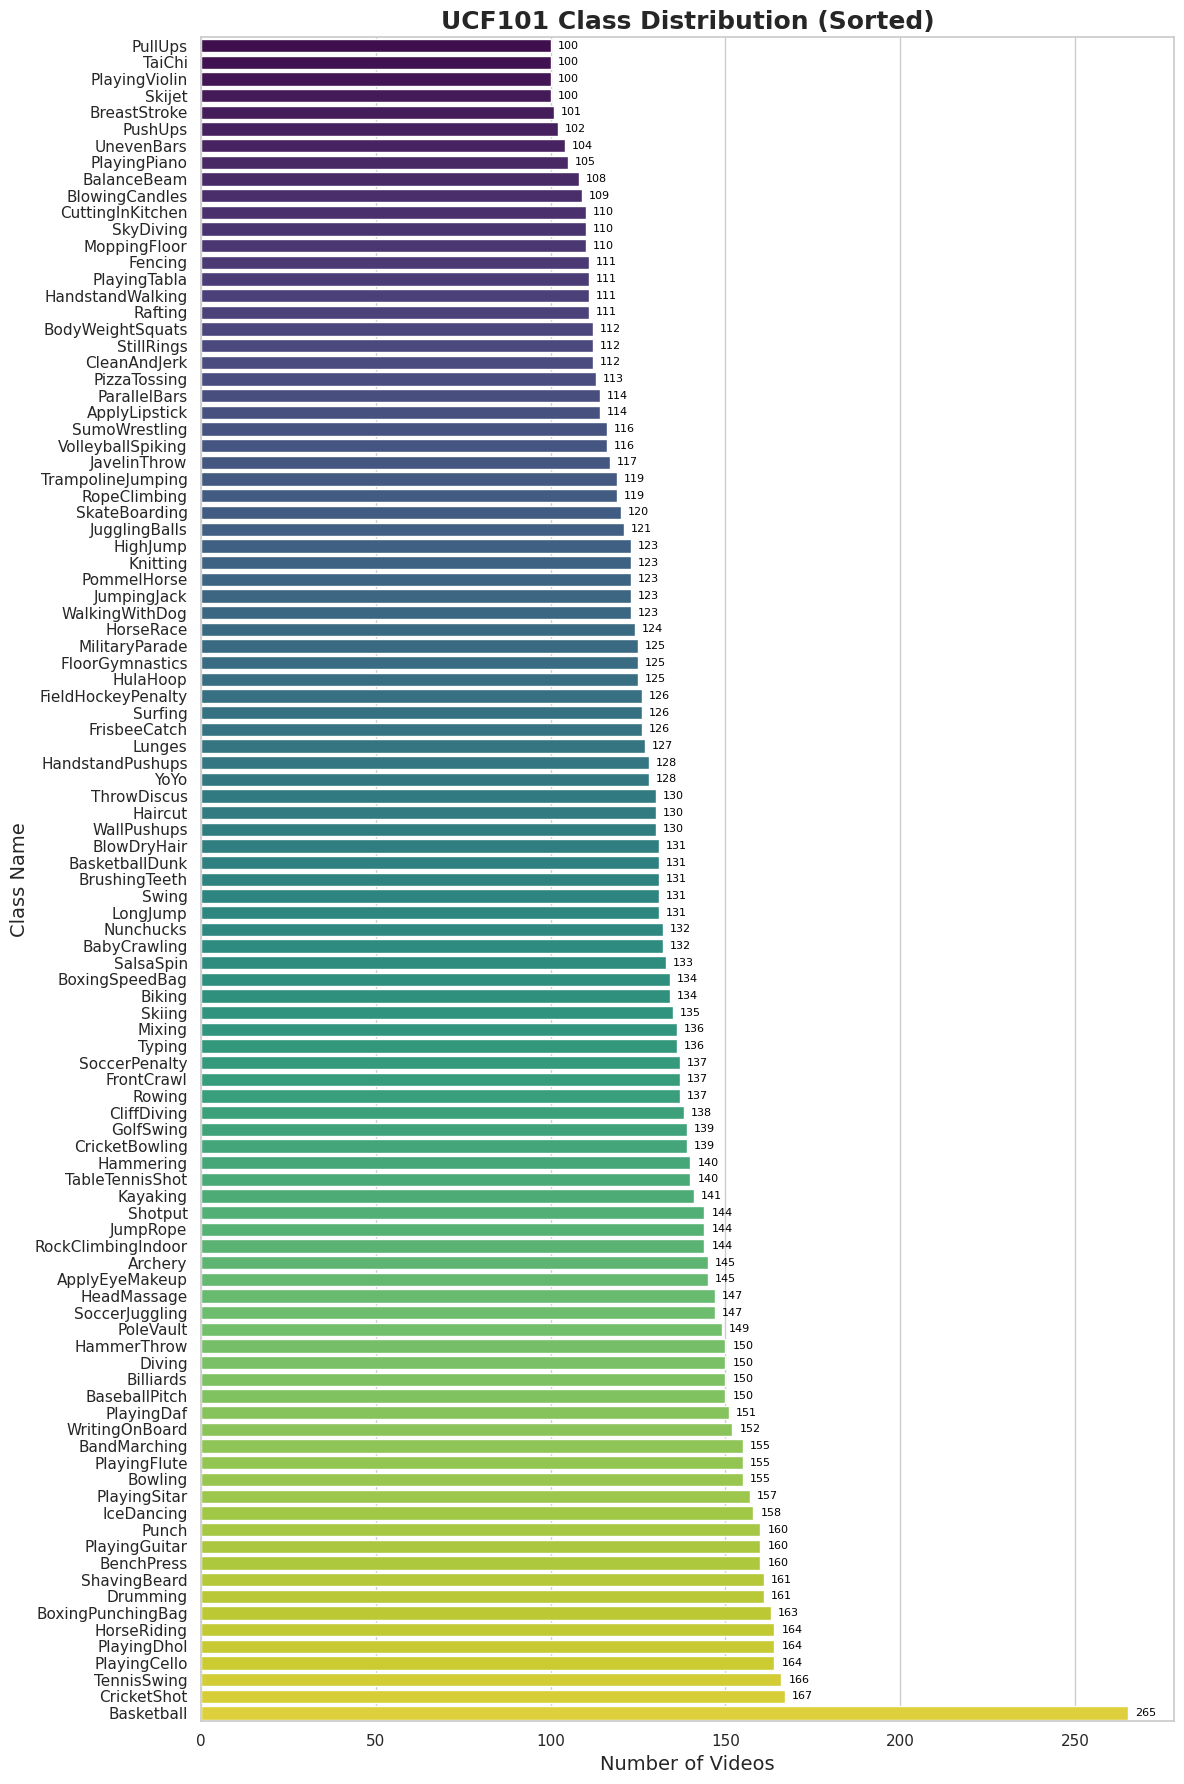

In [ ]:
# counts
class_counts = df['label'].value_counts().reset_index()
class_counts.columns = ["Class", "Count"]
class_counts = class_counts.sort_values("Count", ascending=True)  # ascending so smallest on top

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 18))
barplot = sns.barplot(
    data=class_counts,
    y="Class",
    x="Count",
    hue="Class",
    palette="viridis",
    legend=False,
    dodge=False,
    orient="h"
)
plt.title("UCF101 Class Distribution (Sorted)", fontsize=18, fontweight="bold")
plt.xlabel("Number of Videos", fontsize=14)
plt.ylabel("Class Name", fontsize=14)

for i, v in enumerate(class_counts["Count"]):
    barplot.text(v + 2, i, str(v), color='black', va='center', fontsize=8)

plt.tight_layout()
plt.show()

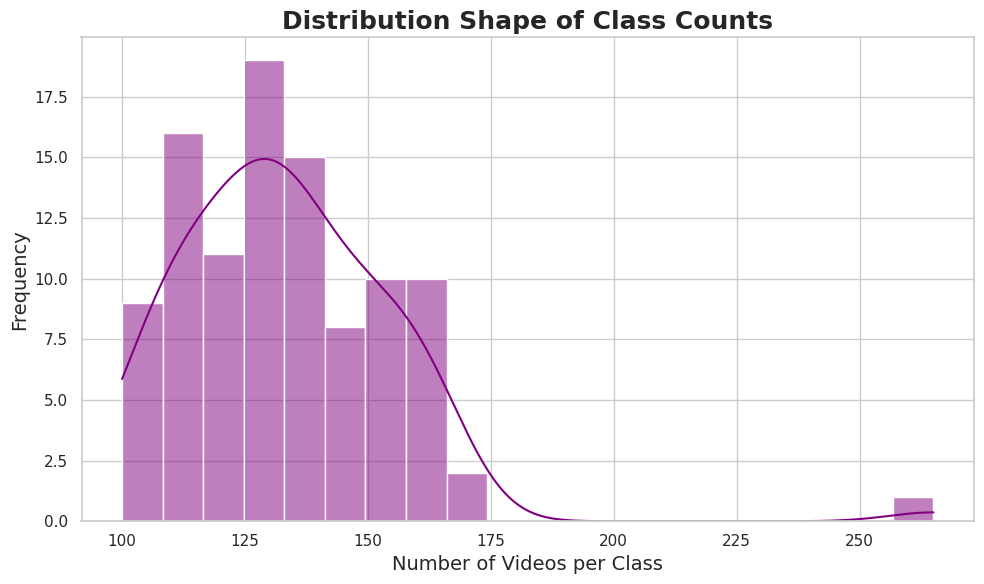

In [ ]:
# distribution shape
plt.figure(figsize=(10, 6))
sns.histplot(class_counts["Count"], bins=20, kde=True, color="purple")
plt.title("Distribution Shape of Class Counts", fontsize=18, fontweight="bold")
plt.xlabel("Number of Videos per Class", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.tight_layout()
plt.show()

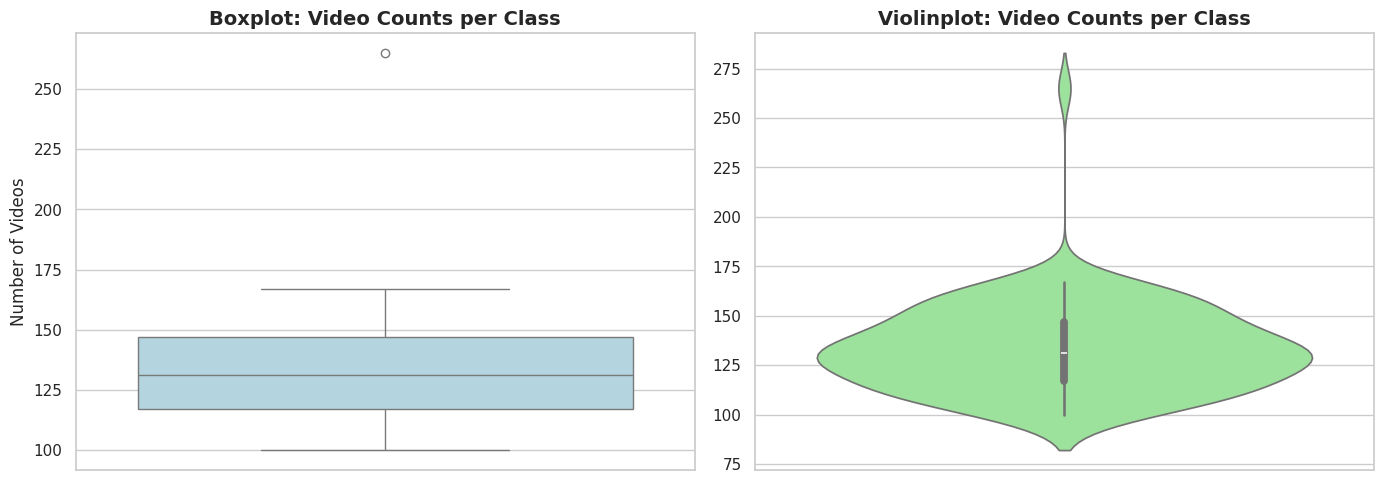

 Outlier Classes Detected (IQR Method):


,Class,Count
0,Basketball,265


In [ ]:
# Outlier detection
# Calculate IQR
Q1 = class_counts["Count"].quantile(0.25)
Q3 = class_counts["Count"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = class_counts[(class_counts["Count"] < lower_bound) | (class_counts["Count"] > upper_bound)]

# boxplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=class_counts["Count"], ax=ax[0], color="lightblue")
ax[0].set_title("Boxplot: Video Counts per Class", fontsize=14, fontweight="bold")
ax[0].set_ylabel("Number of Videos")

# Violinplot
sns.violinplot(y=class_counts["Count"], ax=ax[1], color="lightgreen")
ax[1].set_title("Violinplot: Video Counts per Class", fontsize=14, fontweight="bold")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Print outlier classes
if not outliers.empty:
    print(" Outlier Classes Detected (IQR Method):")
    display(outliers)


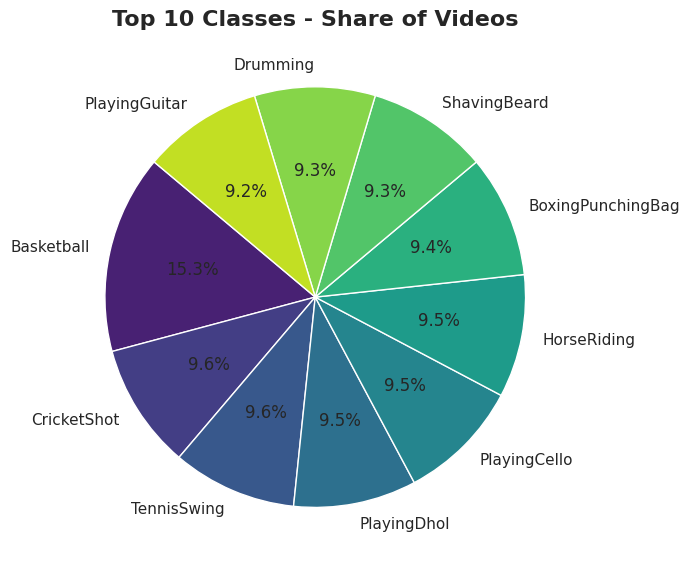

In [ ]:
# pie chart for top 10
top10 = class_counts.sort_values("Count", ascending=False).head(10)

plt.figure(figsize=(7, 7))
plt.pie(
    top10['Count'],
    labels=top10['Class'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("viridis", len(top10))
)
plt.title("Top 10 Classes - Share of Videos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# class balance SCORE (std / mean)
balance_score = class_counts["Count"].std() / class_counts["Count"].mean()
print(f"\n Class Balance Score (std/mean): {balance_score:.3f}")
if balance_score < 0.1:
    print("Dataset is well balanced.")
elif balance_score < 0.3:
    print("Dataset is moderately balanced.")
else:
    print("Dataset is highly imbalanced.")



 Class Balance Score (std/mean): 0.170
Dataset is moderately balanced.


## **Preprocess the data**

In [12]:
preprocess_dataset()

Preprocessing UCF101 (10 classes) from /kaggle/input/ucf101-action-recognition/ -> ./UCF101/processed_data

Processing split: train

  Class: PlayingTabla


PlayingTabla [train]: 100%|██████████| 83/83 [00:11<00:00,  7.43it/s]



  Class: PommelHorse


PommelHorse [train]: 100%|██████████| 92/92 [00:13<00:00,  6.69it/s]



  Class: JumpingJack


...


  Class: BenchPress


BenchPress [test]: 100%|██████████| 20/20 [00:01<00:00, 11.21it/s]



  Class: BaseballPitch


BaseballPitch [test]: 100%|██████████| 19/19 [00:01<00:00, 13.04it/s]


Preprocessing completed successfully!
Processed data saved at: ./UCF101/processed_data


In [13]:
class UCF101Clips(Dataset):
    def __init__(self, root_dir, split="train"):
        self.root = os.path.join(root_dir, split)
        self.classes = sorted(os.listdir(self.root))
        self.samples = []

        for cls_idx, cls_name in enumerate(self.classes):
            clips = glob(os.path.join(self.root, cls_name, "*.pt"))
            for clip in clips:
                self.samples.append((clip, cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = torch.load(path)  # [T, C, H, W]
        return clip, label


In [14]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# classes len
CLASSES_LIST = SELECTED_CLASSES
num_classes = len(CLASSES_LIST)
batch_size = 4

# datasets
train_dataset = UCF101Clips("./UCF101/processed_data", split="train")
val_dataset   = UCF101Clips("./UCF101/processed_data", split="val")
test_dataset  = UCF101Clips("./UCF101/processed_data", split="test")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

for clips, labels in train_loader:
    print(clips.shape)  # [B, T, C, H, W]
    print(labels.shape) # [B]
    break

Using device: cuda
torch.Size([4, 16, 3, 224, 224])
torch.Size([4])


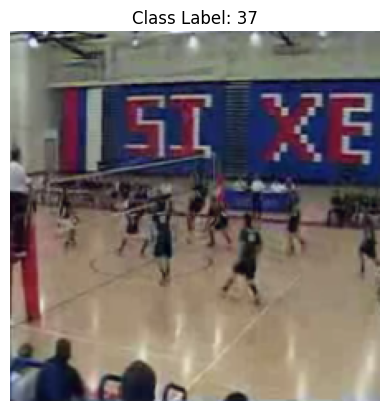

In [15]:
# Take first video clip
first_clip = clips[0]          # Shape: [16, 3, 224, 224]
first_frame = first_clip[0]    # Shape: [3, 224, 224]

# Convert to numpy for visualization
frame_np = first_frame.permute(1, 2, 0).numpy()  # [224, 224, 3]
frame_np = (frame_np - frame_np.min()) / (frame_np.max() - frame_np.min())  # normalize to [0, 1]

plt.imshow(frame_np)
plt.title(f"Class Label: {labels[0].item()}")
plt.axis('off')
plt.show()


In [16]:
print(len(SELECTED_CLASSES))

40


## **FUNCTIONS**

In [17]:
def fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                   num_epochs=10, device='cuda', save_flag=False, save_path='best_model.pth'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for clips, labels in train_loader:
            clips, labels = clips.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(clips)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Val
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for clips, labels in val_loader:
                clips, labels = clips.to(device), labels.to(device)
                outputs = model(clips)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * labels.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # save best if flag True
        if save_flag and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            print(f"  -> Best val loss: {val_loss:.4f}")

    if save_flag and best_model_state is not None:
        torch.save(best_model_state, save_path)
        print(f"Best model saved: {save_path}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_loss': best_val_loss
    }


def test_model_with_predictions(model, test_loader, device='cuda'):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for clips, labels in test_loader:
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    from sklearn.metrics import accuracy_score
    test_acc = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {test_acc:.4f}")

    return test_acc, all_preds, all_labels

In [18]:
def plot_training_results(results):

    plt.figure(figsize=(12,5))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(results['train_losses'], label="Train Loss")
    plt.plot(results['val_losses'], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(results['train_accs'], label="Train Acc")
    plt.plot(results['val_accs'], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()



def plot_confusion_matrix(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST):

    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    # Plot 1: Counts
    plt.figure(figsize=(20, 18))
    ax1 = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                      annot_kws={'size': 6},
                      xticklabels=classes_list[:num_classes],
                      yticklabels=classes_list[:num_classes])
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("True")
    ax1.set_title("Confusion Matrix - Counts (40 Classes)")
    ax1.tick_params(axis='x', rotation=90, labelsize=9)
    ax1.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

    # Plot 2: Normalized
    plt.figure(figsize=(20, 18))
    ax2 = sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', square=True,
                      annot_kws={'size': 6},
                      xticklabels=classes_list[:num_classes],
                      yticklabels=classes_list[:num_classes])
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("True")
    ax2.set_title("Confusion Matrix - Normalized (40 Classes)")
    ax2.tick_params(axis='x', rotation=90, labelsize=9)
    ax2.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()




def print_detailed_metrics(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST):
    # Overall metrics
    overall_f1 = f1_score(all_labels, all_preds, average='weighted')
    overall_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    overall_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    overall_acc = accuracy_score(all_labels, all_preds)

    print("\n\n")
    print("METRICS (Weighted Average)")
    print("\n")
    print(f"Accuracy:     {overall_acc:.4f}")
    print(f"Precision:    {overall_precision:.4f}")
    print(f"Recall:       {overall_recall:.4f}")
    print(f"F1-Score:     {overall_f1:.4f}")
    print("\n\n")

    # Per-class detailed report
    print("PER-CLASS METRICS")
    print("\n")
    print(classification_report(all_labels, all_preds,
                              labels=np.arange(num_classes),
                              target_names=classes_list[:num_classes],
                              zero_division=0))

    # Top 5 best/worst classes by F1
    f1_per_class = f1_score(all_labels, all_preds, average=None, labels=np.arange(num_classes), zero_division=0)
    best_classes = np.argsort(f1_per_class)[-5:][::-1]
    worst_classes = np.argsort(f1_per_class)[:5]

    print("\nTOP 5 BEST CLASSES (F1-Score):")
    for idx in best_classes:
        print(f"  {classes_list[idx]:20s}: {f1_per_class[idx]:.4f}")

    print("\nTOP 5 WORST CLASSES (F1-Score):")
    for idx in worst_classes:
        print(f"  {classes_list[idx]:20s}: {f1_per_class[idx]:.4f}")


## **RESNET18 + LSTM**

In [ ]:
class ResNet18LSTM(nn.Module):
    def __init__(self, hidden_size=256, num_classes=num_classes):
        super(ResNet18LSTM, self).__init__()
        resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # freeze all layers
        for param in resnet.parameters():
            param.requires_grad = False

        # unfreeze only layer4
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove fc

        self.lstm = nn.LSTM(input_size=512, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        # remove torch.no_grad() so gradients go through unfrozen layer4
        features = self.resnet(x)  # [B*T, 512, 1, 1]
        features = features.view(batch_size, seq_len, -1)  # [B, T, 512]
        lstm_out, _ = self.lstm(features)
        output = self.fc(lstm_out[:, -1, :])  # take last hidden state
        return output

In [ ]:
# model
model = ResNet18LSTM().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


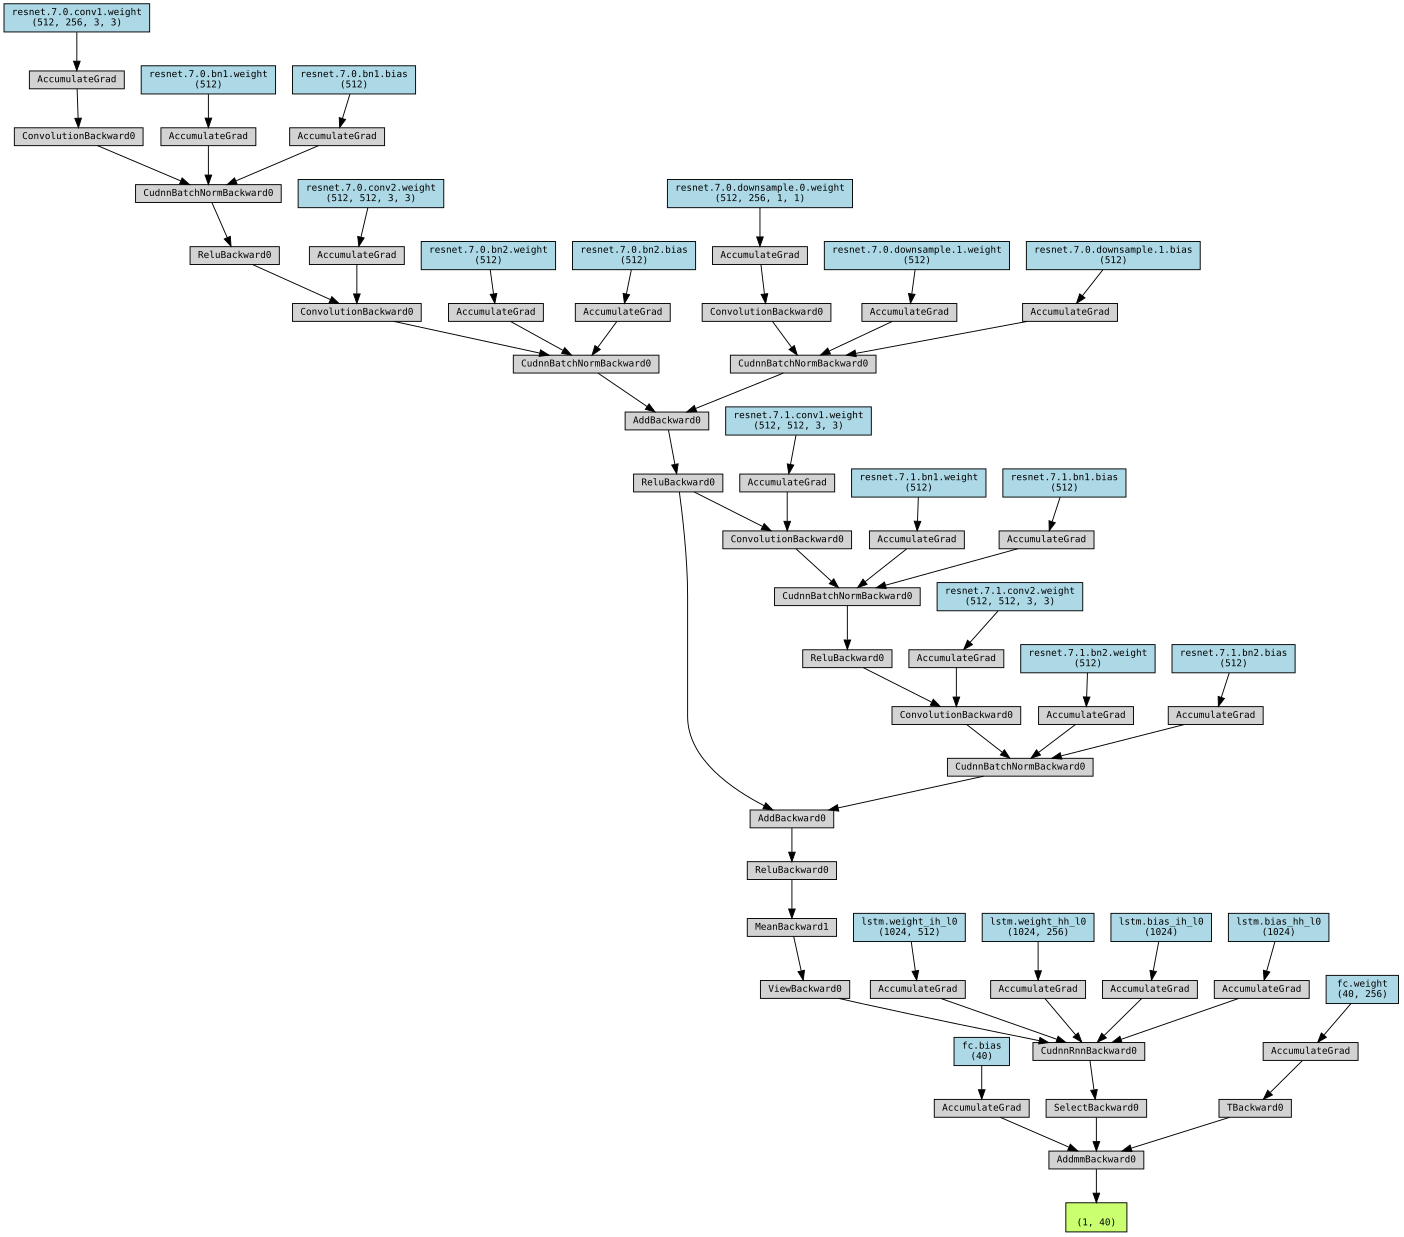

In [ ]:
x = torch.randn(1, 16, 3, 224, 224).to(device)
y = model(x)

make_dot(y, params=dict(model.named_parameters()))

In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 2.2387 Acc: 0.4937 | Val Loss: 1.0192 Acc: 0.7752
Epoch [2/10] Train Loss: 1.0895 Acc: 0.7805 | Val Loss: 0.5255 Acc: 0.8946
Epoch [3/10] Train Loss: 0.6640 Acc: 0.8731 | Val Loss: 0.3659 Acc: 0.9085
Epoch [4/10] Train Loss: 0.4729 Acc: 0.9090 | Val Loss: 0.2684 Acc: 0.9380
Epoch [5/10] Train Loss: 0.3346 Acc: 0.9368 | Val Loss: 0.2398 Acc: 0.9395
Epoch [6/10] Train Loss: 0.2532 Acc: 0.9567 | Val Loss: 0.1942 Acc: 0.9488
Epoch [7/10] Train Loss: 0.1944 Acc: 0.9626 | Val Loss: 0.1999 Acc: 0.9426
Epoch [8/10] Train Loss: 0.1762 Acc: 0.9683 | Val Loss: 0.2094 Acc: 0.9395
Epoch [9/10] Train Loss: 0.1573 Acc: 0.9750 | Val Loss: 0.1865 Acc: 0.9395
Epoch [10/10] Train Loss: 0.1481 Acc: 0.9685 | Val Loss: 0.2286 Acc: 0.9442


In [ ]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9563


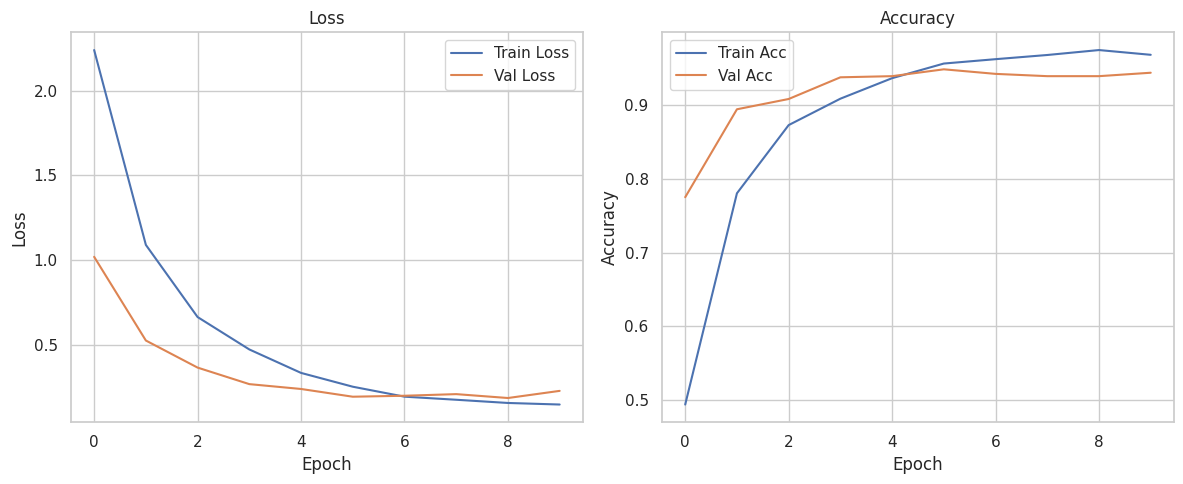

In [ ]:
# plot results
plot_training_results(results)

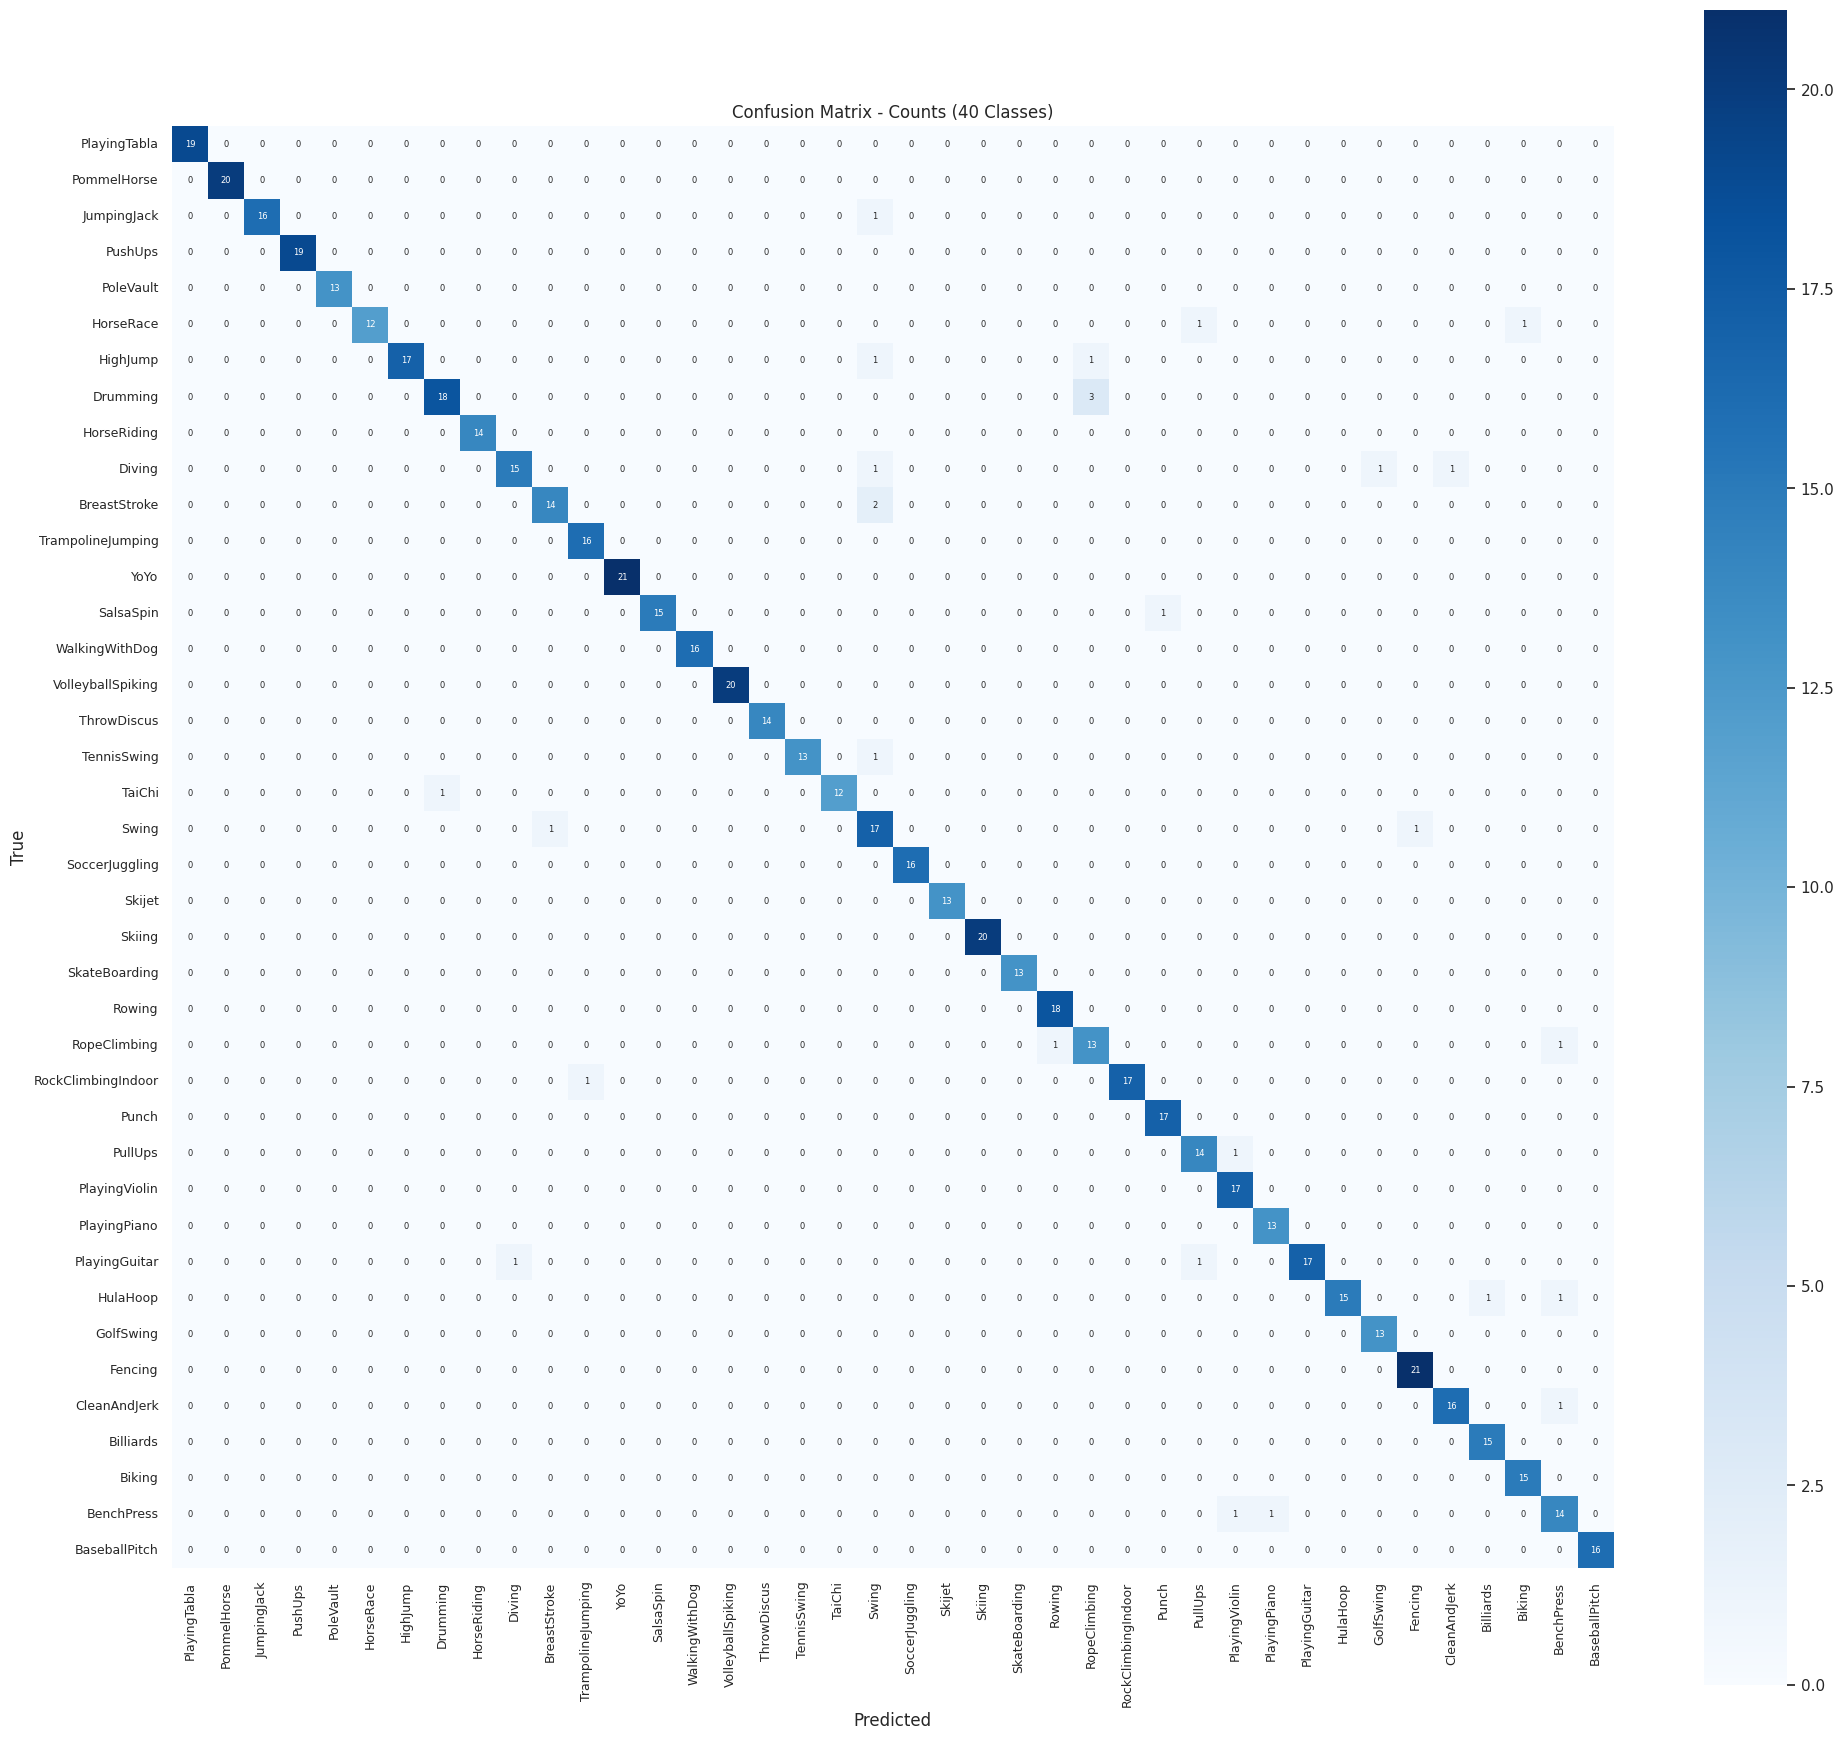

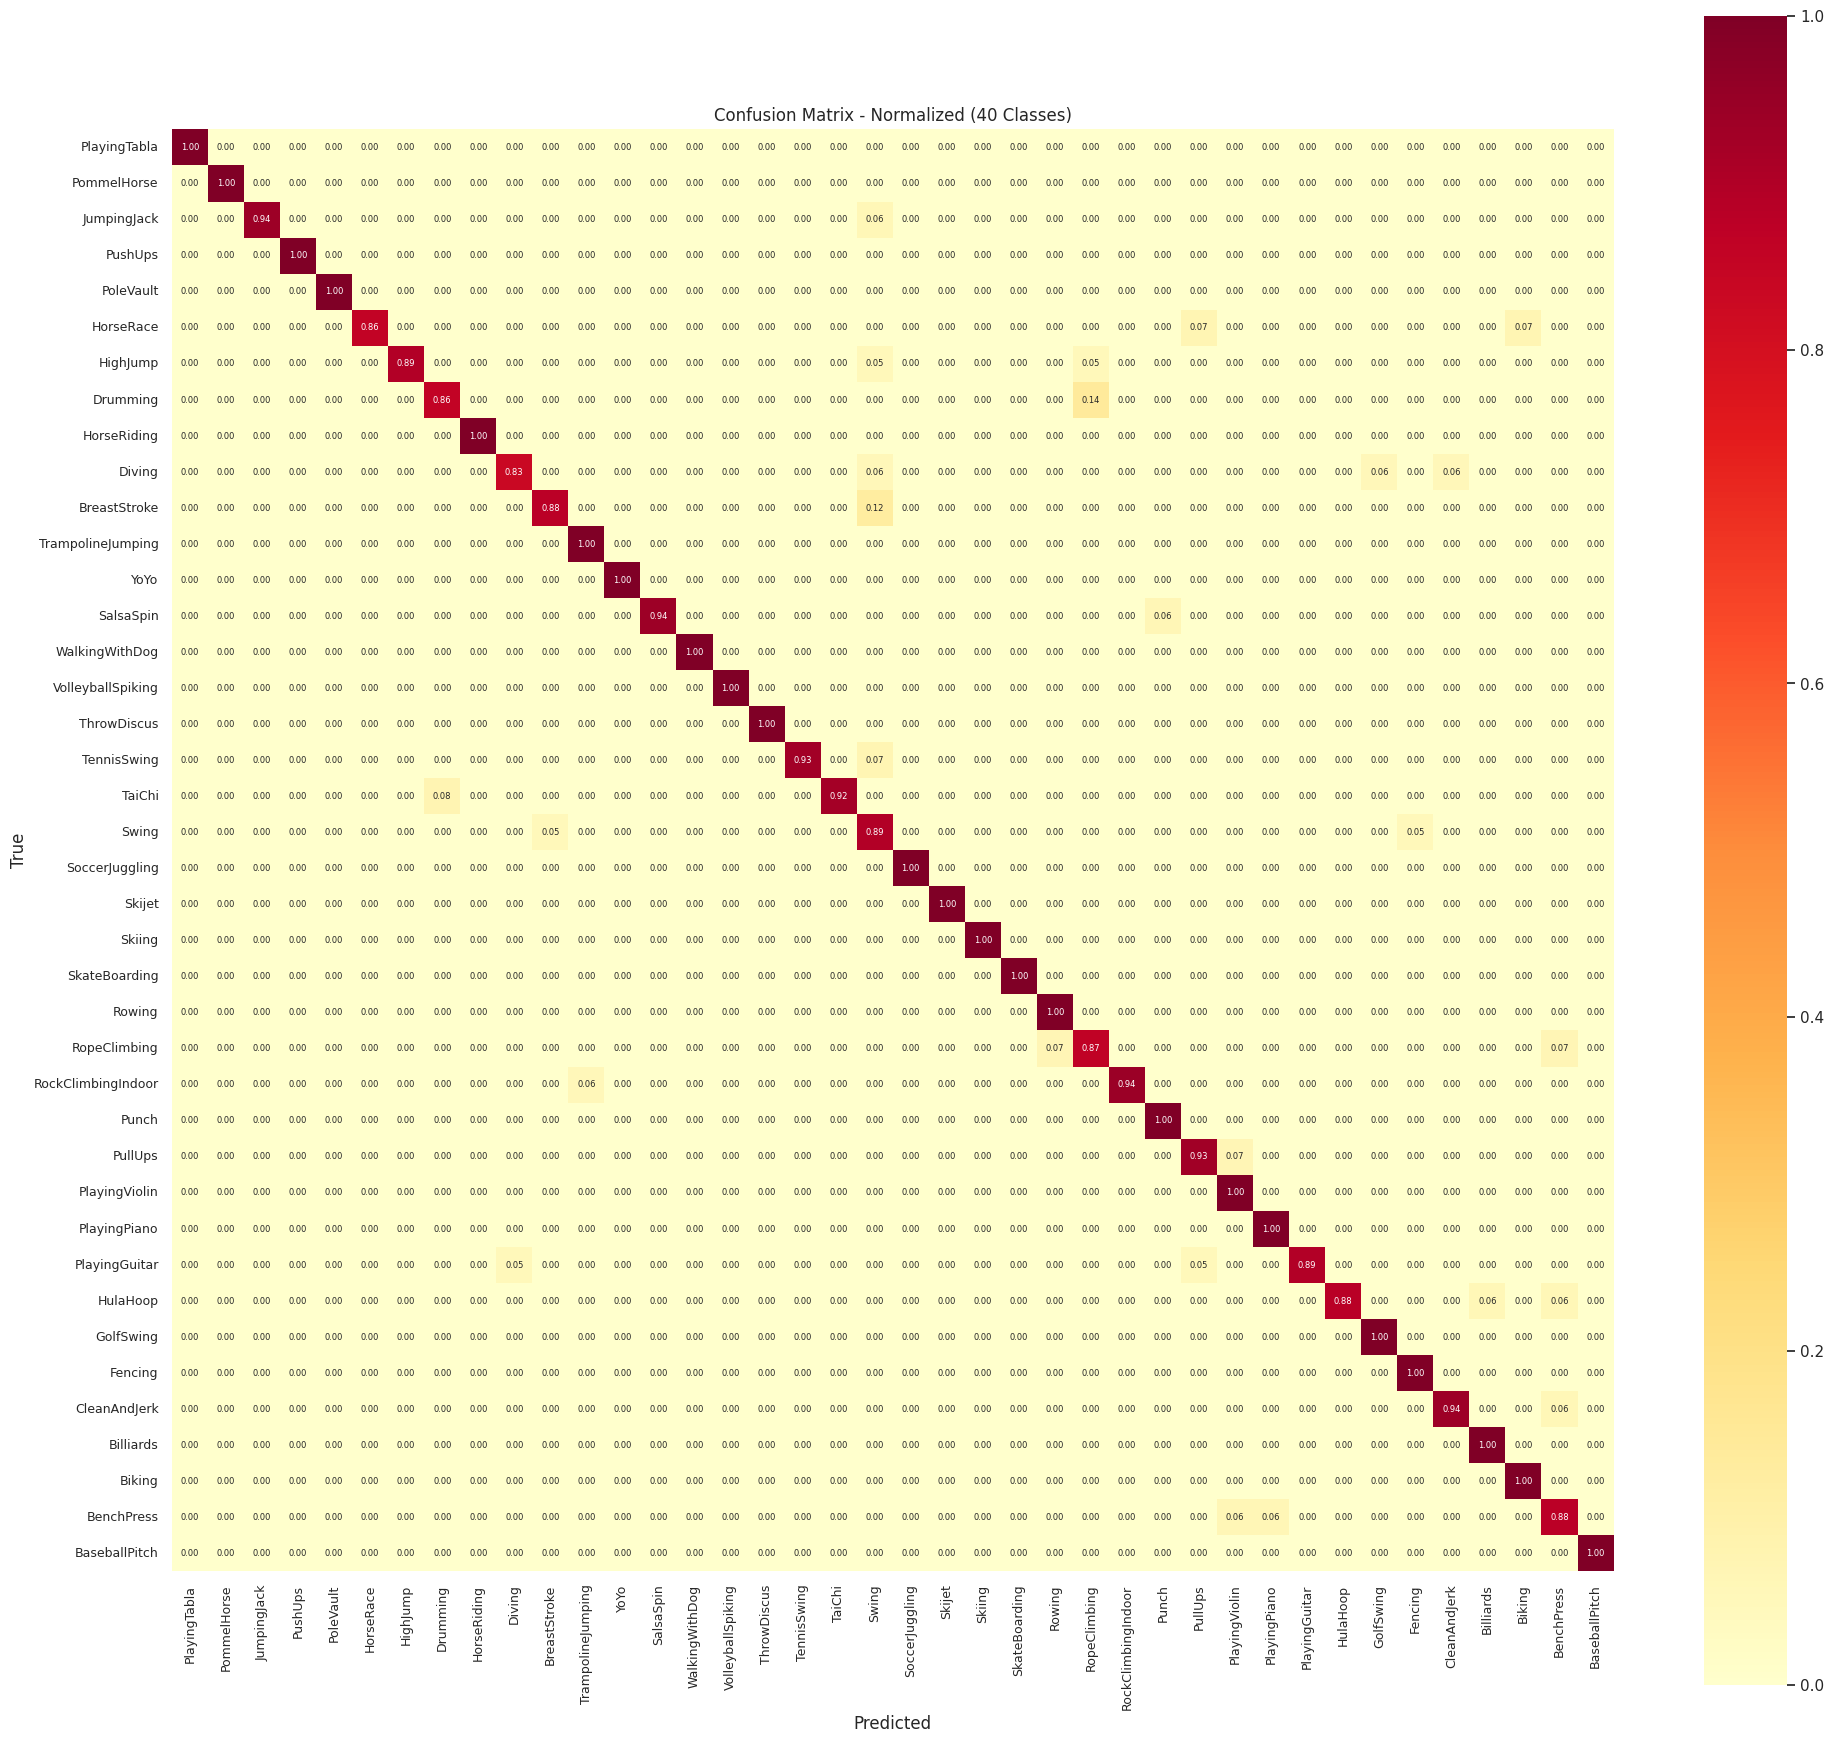

In [ ]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)

In [ ]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)




METRICS (Weighted Average)


Accuracy:     0.9563
Precision:    0.9596
Recall:       0.9563
F1-Score:     0.9567



PER-CLASS METRICS


                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        19
       PommelHorse       1.00      1.00      1.00        20
       JumpingJack       1.00      0.94      0.97        17
           PushUps       1.00      1.00      1.00        19
         PoleVault       1.00      1.00      1.00        13
         HorseRace       1.00      0.86      0.92        14
          HighJump       1.00      0.89      0.94        19
          Drumming       0.95      0.86      0.90        21
       HorseRiding       1.00      1.00      1.00        14
            Diving       0.94      0.83      0.88        18
      BreastStroke       0.93      0.88      0.90        16
 TrampolineJumping       0.94      1.00      0.97        16
              YoYo       1.00      1.00      1.00        21
         SalsaSpin  

## **RESNET50 + LSTM**

In [ ]:
class ResNet50LSTM(nn.Module):
    def __init__(self, hidden_size=256, num_classes=num_classes):
        super(ResNet50LSTM, self).__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)

        # freeze all layers
        for param in resnet.parameters():
            param.requires_grad = False

        # unfreeze only layer4
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove fc

        self.lstm = nn.LSTM(input_size=2048, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        # remove torch.no_grad() gradients go through unfrozen layers
        features = self.resnet(x)  # [B*T, 2048, 1, 1]
        features = features.view(batch_size, seq_len, -1)  # [B, T, 2048]
        lstm_out, _ = self.lstm(features)
        output = self.fc(lstm_out[:, -1, :])  # last hidden state
        return output

In [ ]:
model_ResNet50 = ResNet50LSTM().to(device)

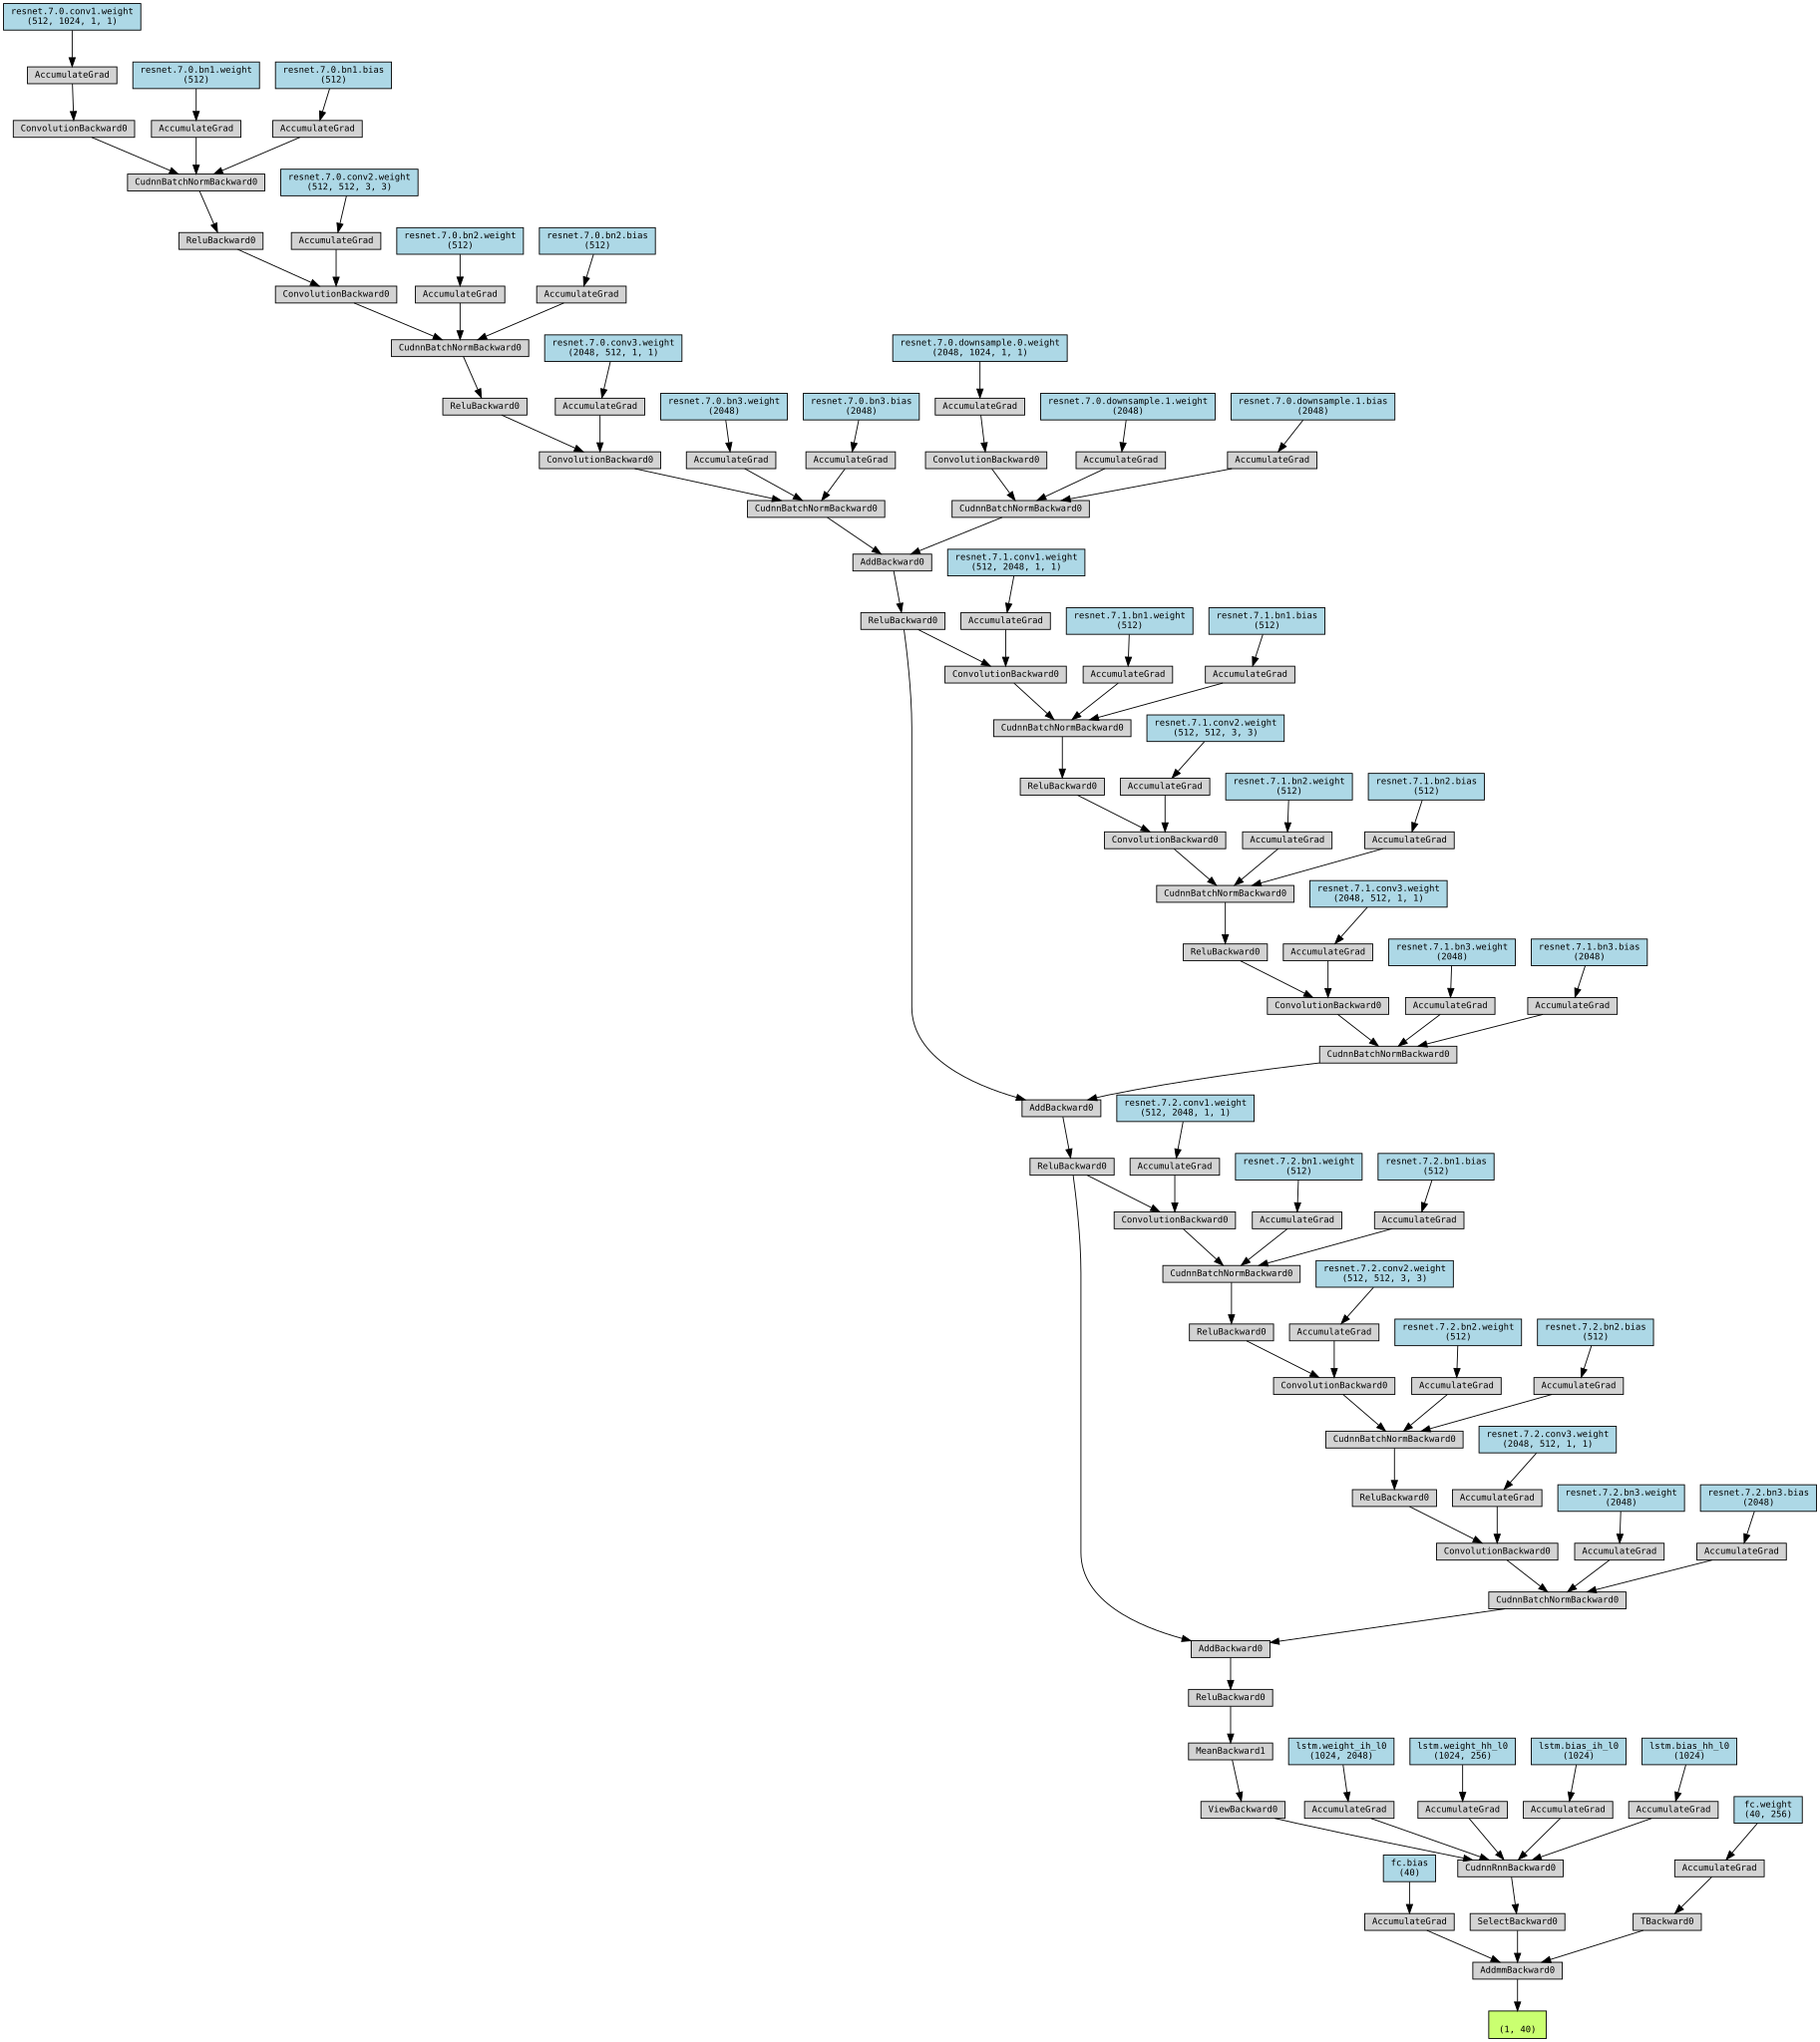

In [ ]:
x = torch.randn(1, 16, 3, 224, 224).to(device)
y = model_ResNet50(x)

make_dot(y, params=dict(model_ResNet50.named_parameters()))

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ResNet50.parameters(), lr=1e-4)

#### **create folder on drive**

In [ ]:
# conect drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# path
base_path = '/content/drive/MyDrive/apai/resnet50'

# folders
folders = ['models', 'features']

# create folders
for folder in folders:
    path = os.path.join(base_path, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/apai/resnet50/models
Created: /content/drive/MyDrive/apai/resnet50/features


In [ ]:
# fine tune
results = fine_tune_model(model_ResNet50, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=True, save_path='/content/drive/MyDrive/apai/resnet50/models/ResNet50_40C.pth')

Epoch [1/10] Train Loss: 2.0284 Acc: 0.5223 | Val Loss: 0.7764 Acc: 0.8357
  -> Best val loss: 0.7764
Epoch [2/10] Train Loss: 0.6660 Acc: 0.8641 | Val Loss: 0.3343 Acc: 0.9240
  -> Best val loss: 0.3343
Epoch [3/10] Train Loss: 0.3252 Acc: 0.9337 | Val Loss: 0.2490 Acc: 0.9411
  -> Best val loss: 0.2490
Epoch [4/10] Train Loss: 0.1690 Acc: 0.9667 | Val Loss: 0.1632 Acc: 0.9581
  -> Best val loss: 0.1632
Epoch [5/10] Train Loss: 0.1158 Acc: 0.9747 | Val Loss: 0.2432 Acc: 0.9380
Epoch [6/10] Train Loss: 0.0998 Acc: 0.9791 | Val Loss: 0.1892 Acc: 0.9519
Epoch [7/10] Train Loss: 0.0752 Acc: 0.9835 | Val Loss: 0.2145 Acc: 0.9442
Epoch [8/10] Train Loss: 0.0585 Acc: 0.9887 | Val Loss: 0.2345 Acc: 0.9333
Epoch [9/10] Train Loss: 0.0582 Acc: 0.9887 | Val Loss: 0.2244 Acc: 0.9426
Epoch [10/10] Train Loss: 0.0507 Acc: 0.9884 | Val Loss: 0.1707 Acc: 0.9535
Best model saved: /content/drive/MyDrive/apai/resnet50/models/ResNet50_40C.pth


### UPLOAD BEST SAVED

In [ ]:
model_path = '/content/drive/MyDrive/apai/resnet50/models/ResNet50_40C.pth'

# model for feature extraction
model_ResNet50 = ResNet50LSTM(hidden_size=256, num_classes=40).to(device)
checkpoint = torch.load(model_path, map_location=device)
model_ResNet50.load_state_dict(checkpoint)

<All keys matched successfully>

In [ ]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model_ResNet50, test_loader, device=device)

Test Accuracy: 0.9668


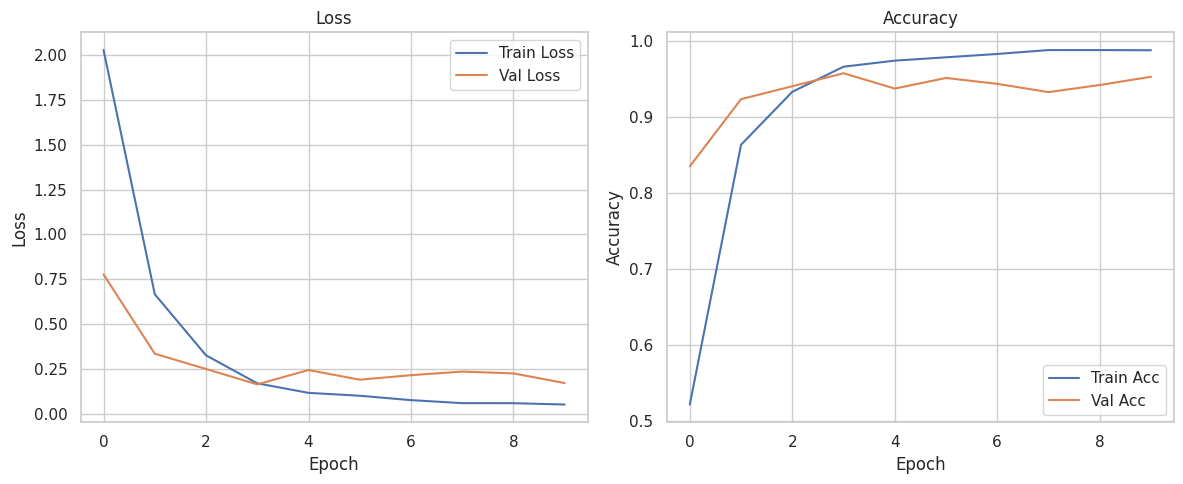

In [ ]:
# plot results
plot_training_results(results)

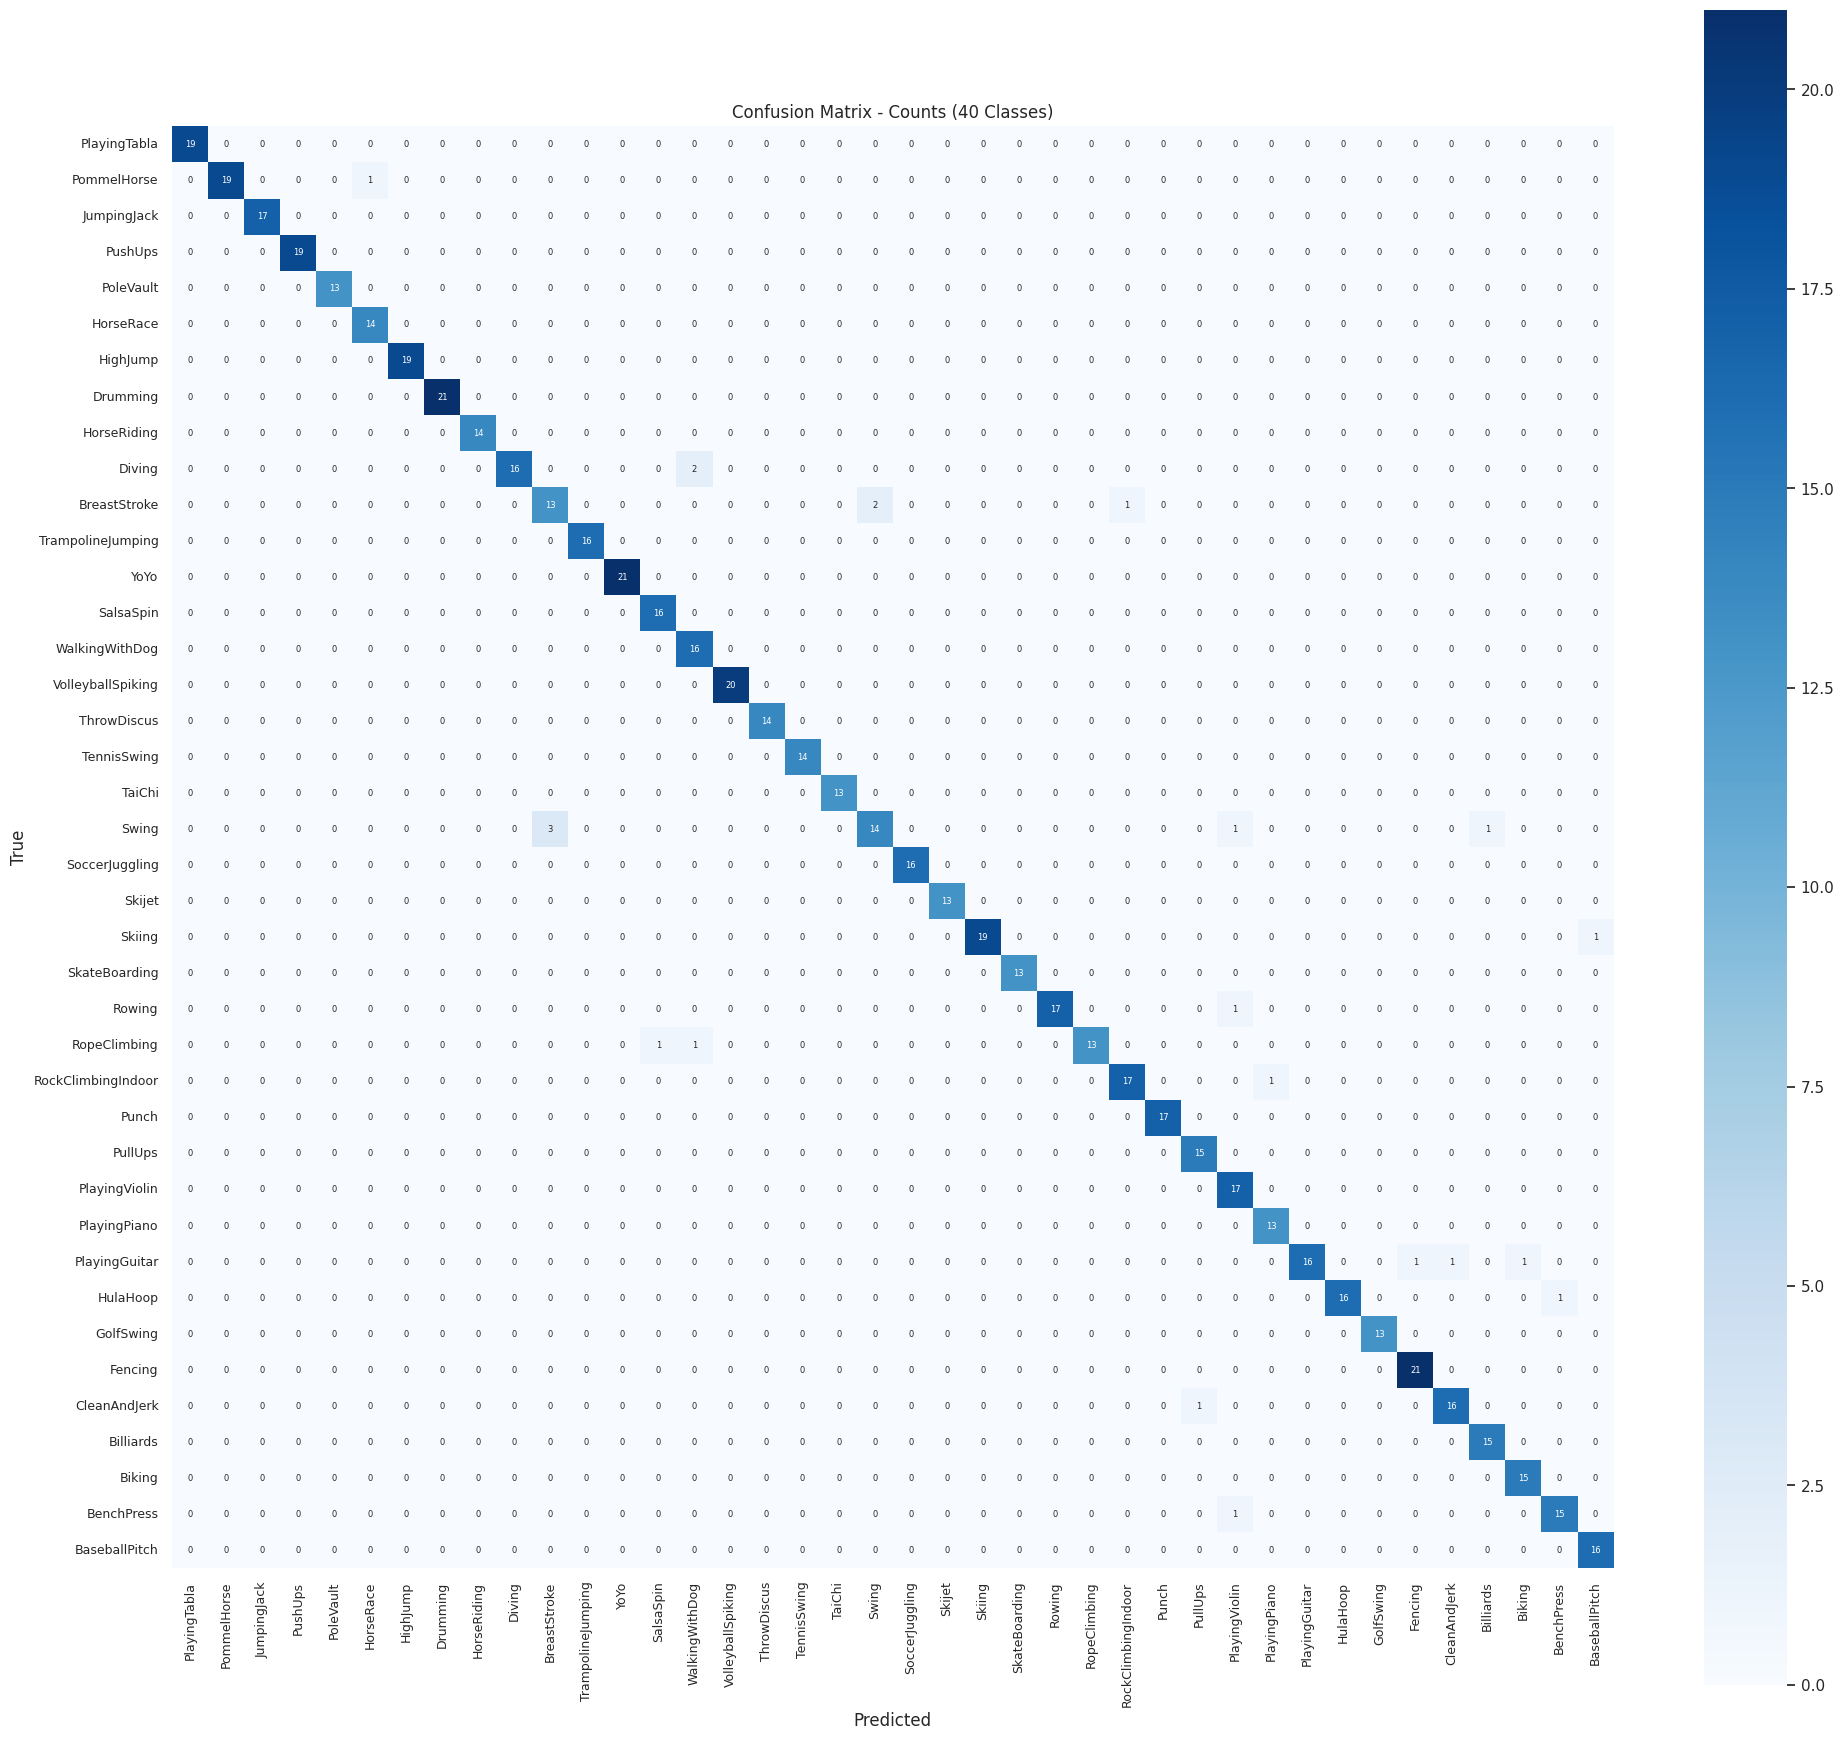

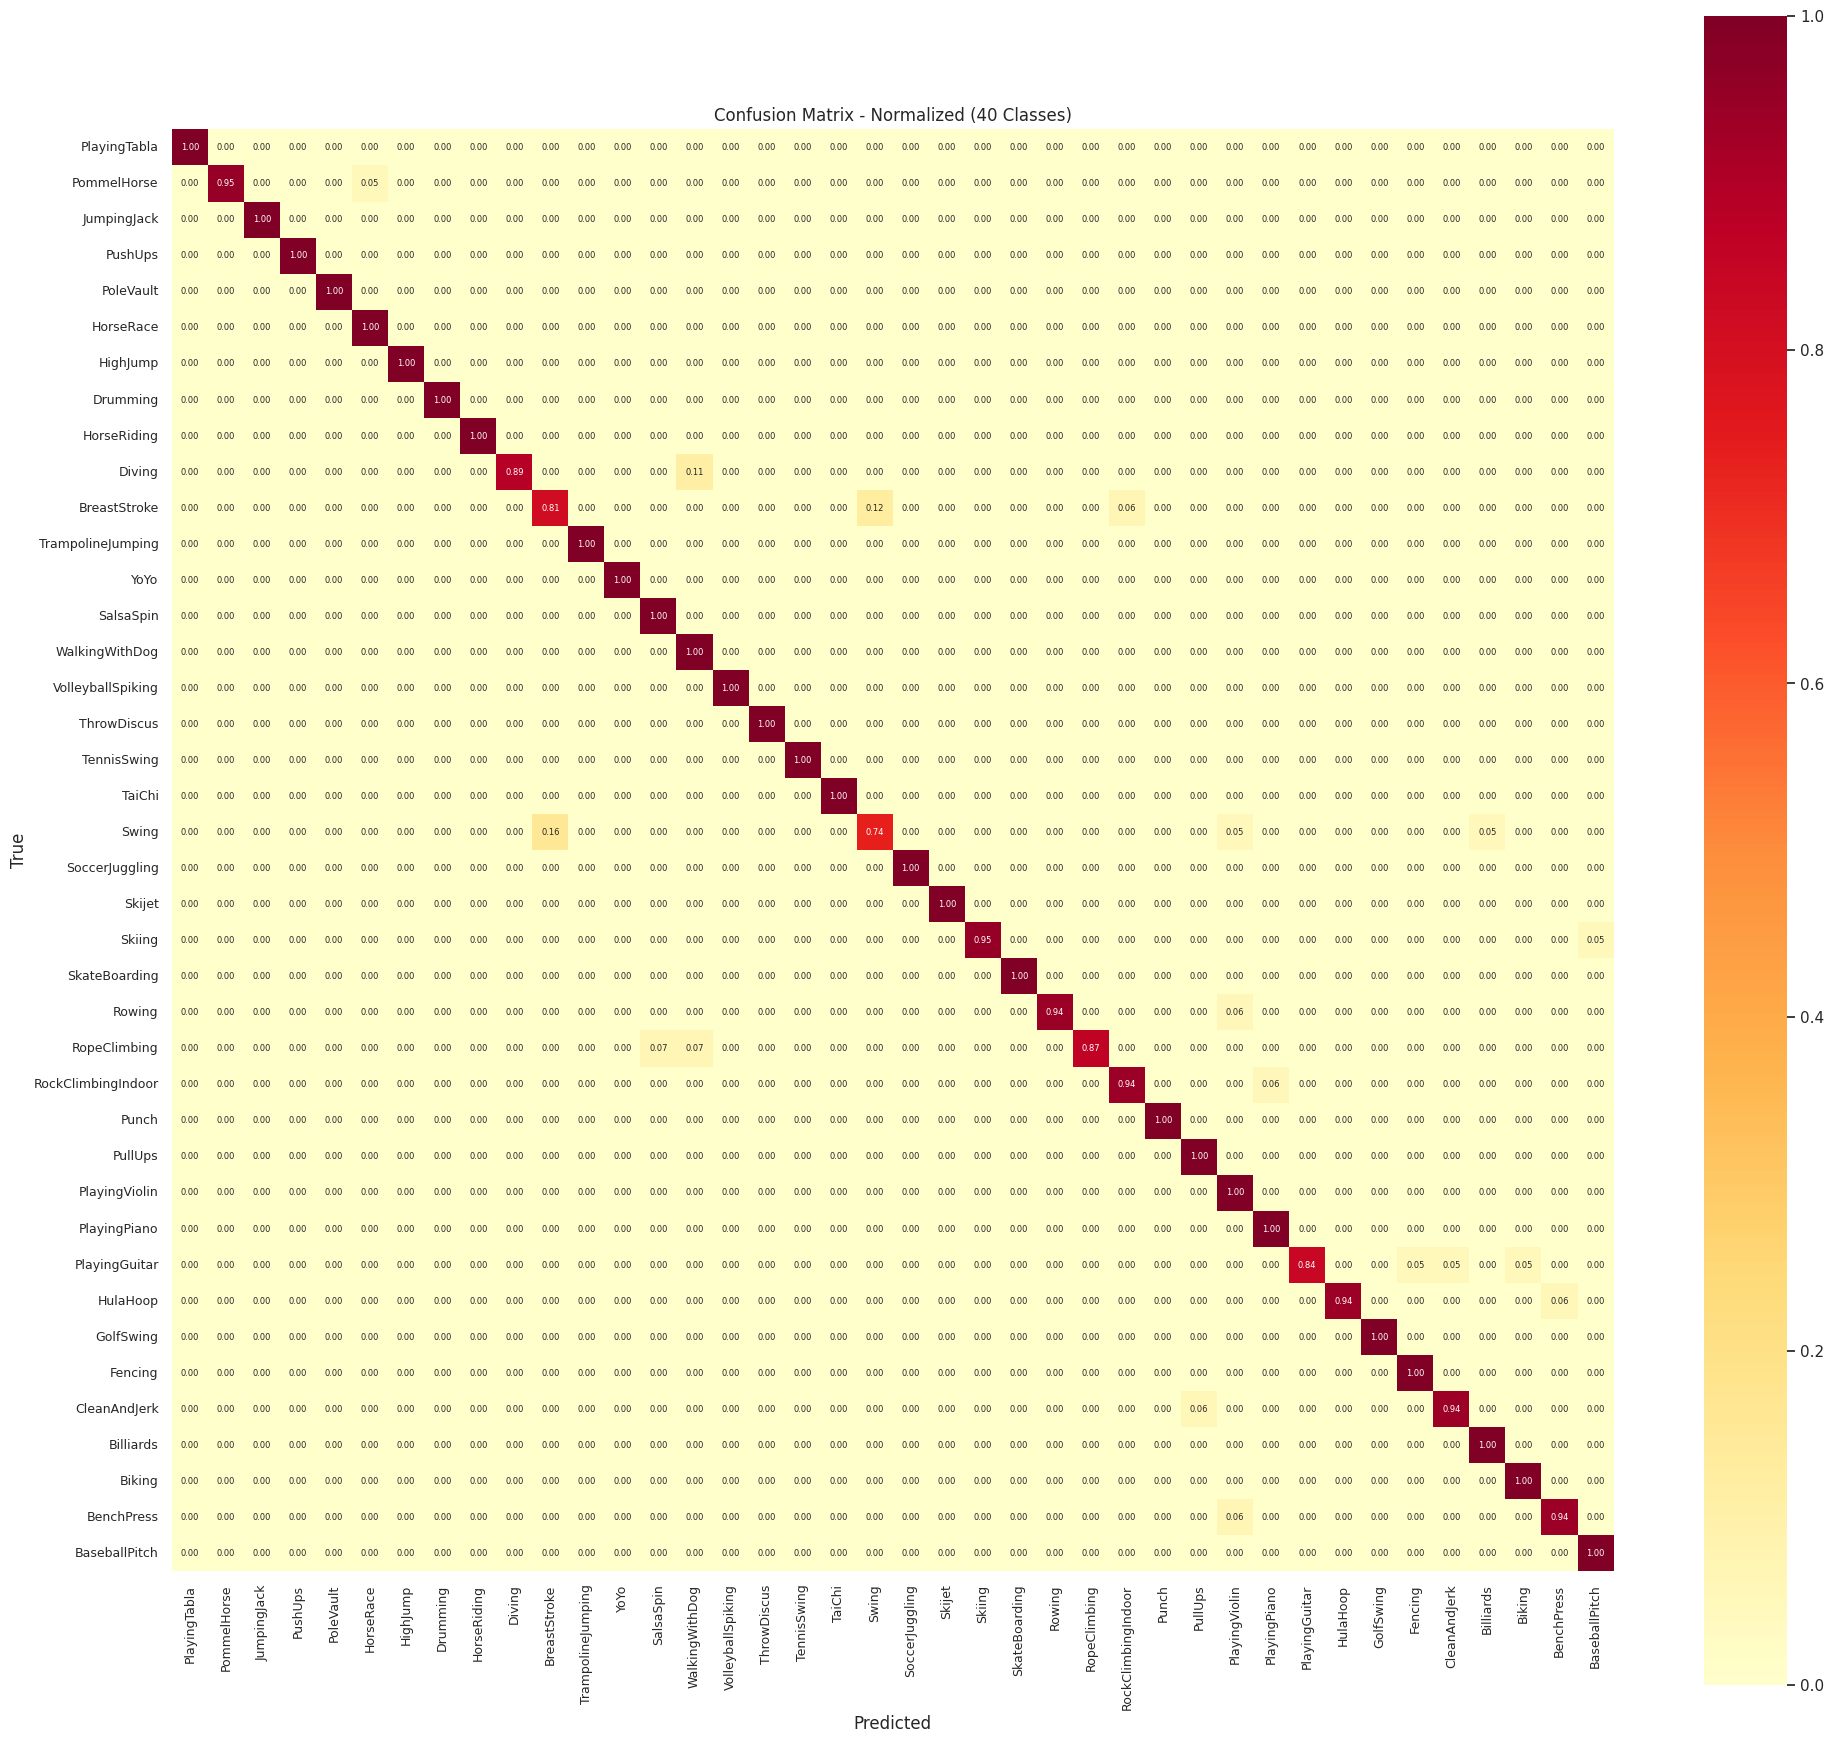

In [ ]:
# plot cm
plot_confusion_matrix(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)

In [ ]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)




METRICS (Weighted Average)


Accuracy:     0.9668
Precision:    0.9684
Recall:       0.9668
F1-Score:     0.9665



PER-CLASS METRICS


                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        19
       PommelHorse       1.00      0.95      0.97        20
       JumpingJack       1.00      1.00      1.00        17
           PushUps       1.00      1.00      1.00        19
         PoleVault       1.00      1.00      1.00        13
         HorseRace       0.93      1.00      0.97        14
          HighJump       1.00      1.00      1.00        19
          Drumming       1.00      1.00      1.00        21
       HorseRiding       1.00      1.00      1.00        14
            Diving       1.00      0.89      0.94        18
      BreastStroke       0.81      0.81      0.81        16
 TrampolineJumping       1.00      1.00      1.00        16
              YoYo       1.00      1.00      1.00        21
         SalsaSpin  

## **DenseNet121 + LSTM**

In [19]:
class DenseNet121_LSTM(nn.Module):
    def __init__(self, hidden_size=256, num_classes=101):
        super(DenseNet121_LSTM, self).__init__()

        dnet = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

        # Freeze all conv layers first
        for p in dnet.features.parameters():
            p.requires_grad = False

        # Unfreeze last dense block + final norm (fine-tune high-level features)
        for p in dnet.features.denseblock4.parameters():
            p.requires_grad = True
        for p in dnet.features.norm5.parameters():
            p.requires_grad = True

        self.features = dnet.features      # CNN backbone (2D)
        self.feature_dim = 1024            # DenseNet-121 last feature channels

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        feats = self.features(x)           # [B*T, 1024, H', W']
        feats = feats.mean(dim=[2, 3])     # GAP -> [B*T, 1024]

        feats = feats.view(B, T, -1)       # [B, T, 1024]
        lstm_out, _ = self.lstm(feats)     # [B, T, hidden]
        out = self.fc(lstm_out[:, -1, :])  # [B, 101]
        return out

In [20]:
model = DenseNet121_LSTM().to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 136MB/s]


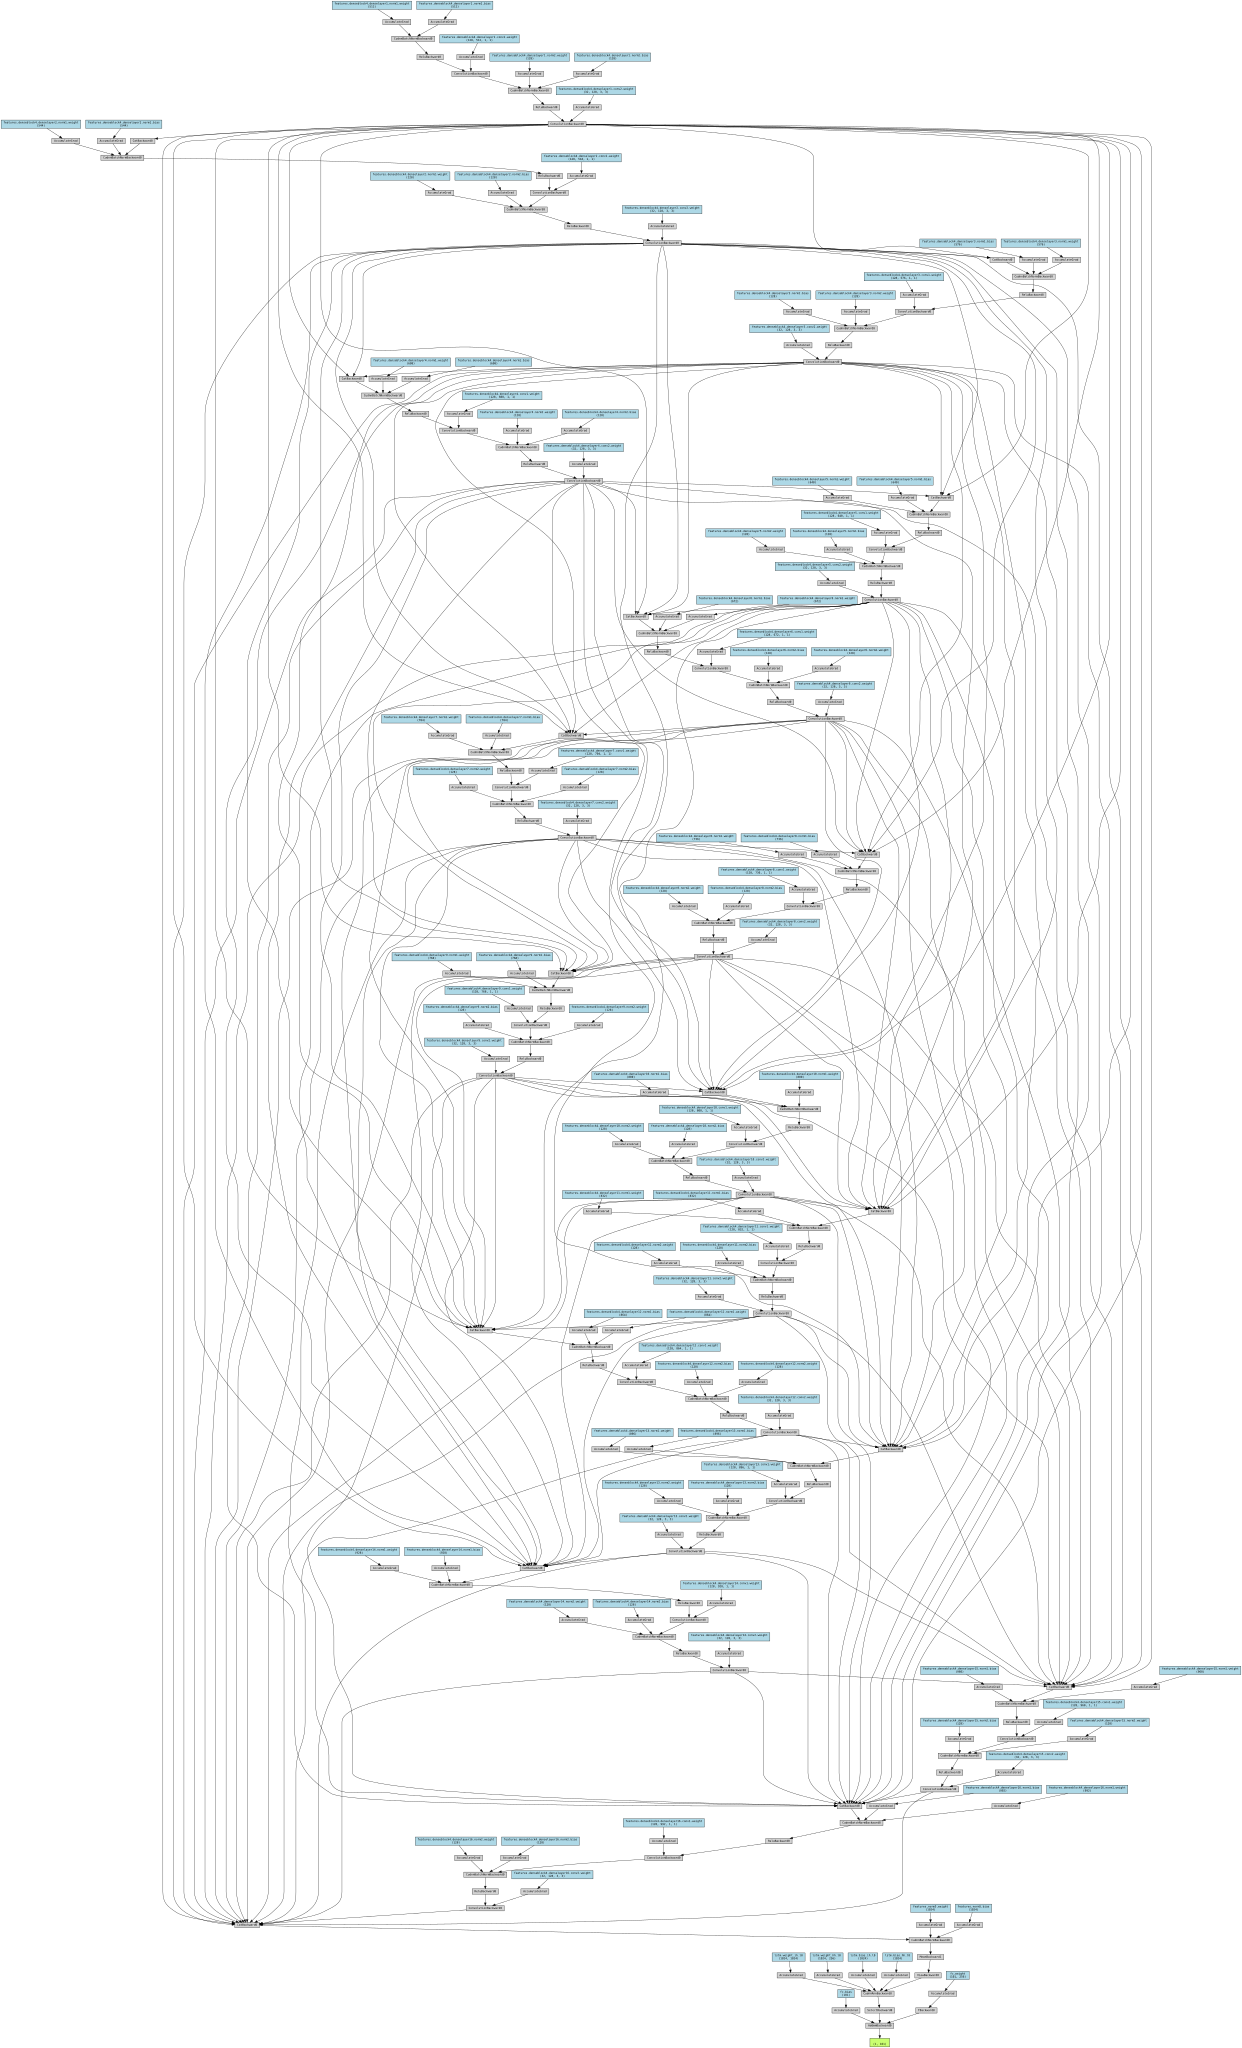

In [21]:
x = torch.randn(1, 16, 3, 224, 224).to(device)
y = model(x)

make_dot(y, params=dict(model.named_parameters()))

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [25]:
# fine-tune
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 2.4858 Acc: 0.4800 | Val Loss: 1.1434 Acc: 0.8000
Epoch [2/10] Train Loss: 1.1087 Acc: 0.7906 | Val Loss: 0.6139 Acc: 0.8760
Epoch [3/10] Train Loss: 0.7062 Acc: 0.8723 | Val Loss: 0.4484 Acc: 0.8853
Epoch [4/10] Train Loss: 0.5064 Acc: 0.9069 | Val Loss: 0.3400 Acc: 0.9240
Epoch [5/10] Train Loss: 0.3815 Acc: 0.9275 | Val Loss: 0.2708 Acc: 0.9302
Epoch [6/10] Train Loss: 0.3254 Acc: 0.9384 | Val Loss: 0.2204 Acc: 0.9581
Epoch [7/10] Train Loss: 0.2449 Acc: 0.9559 | Val Loss: 0.2371 Acc: 0.9411
Epoch [8/10] Train Loss: 0.2041 Acc: 0.9626 | Val Loss: 0.1916 Acc: 0.9488
Epoch [9/10] Train Loss: 0.1857 Acc: 0.9649 | Val Loss: 0.1866 Acc: 0.9535
Epoch [10/10] Train Loss: 0.1373 Acc: 0.9770 | Val Loss: 0.1513 Acc: 0.9581


In [26]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9668


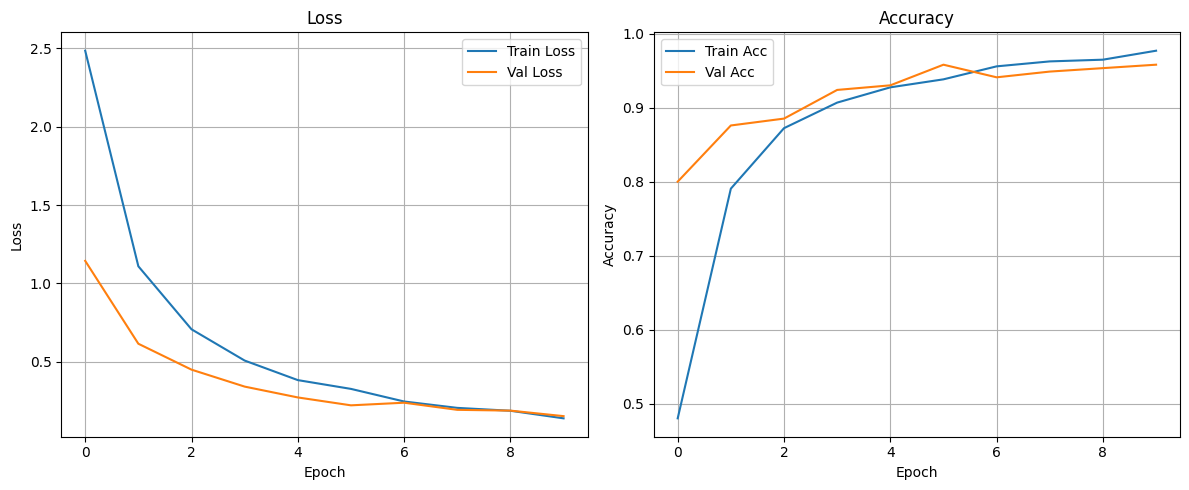

In [27]:
# plot results
plot_training_results(results)

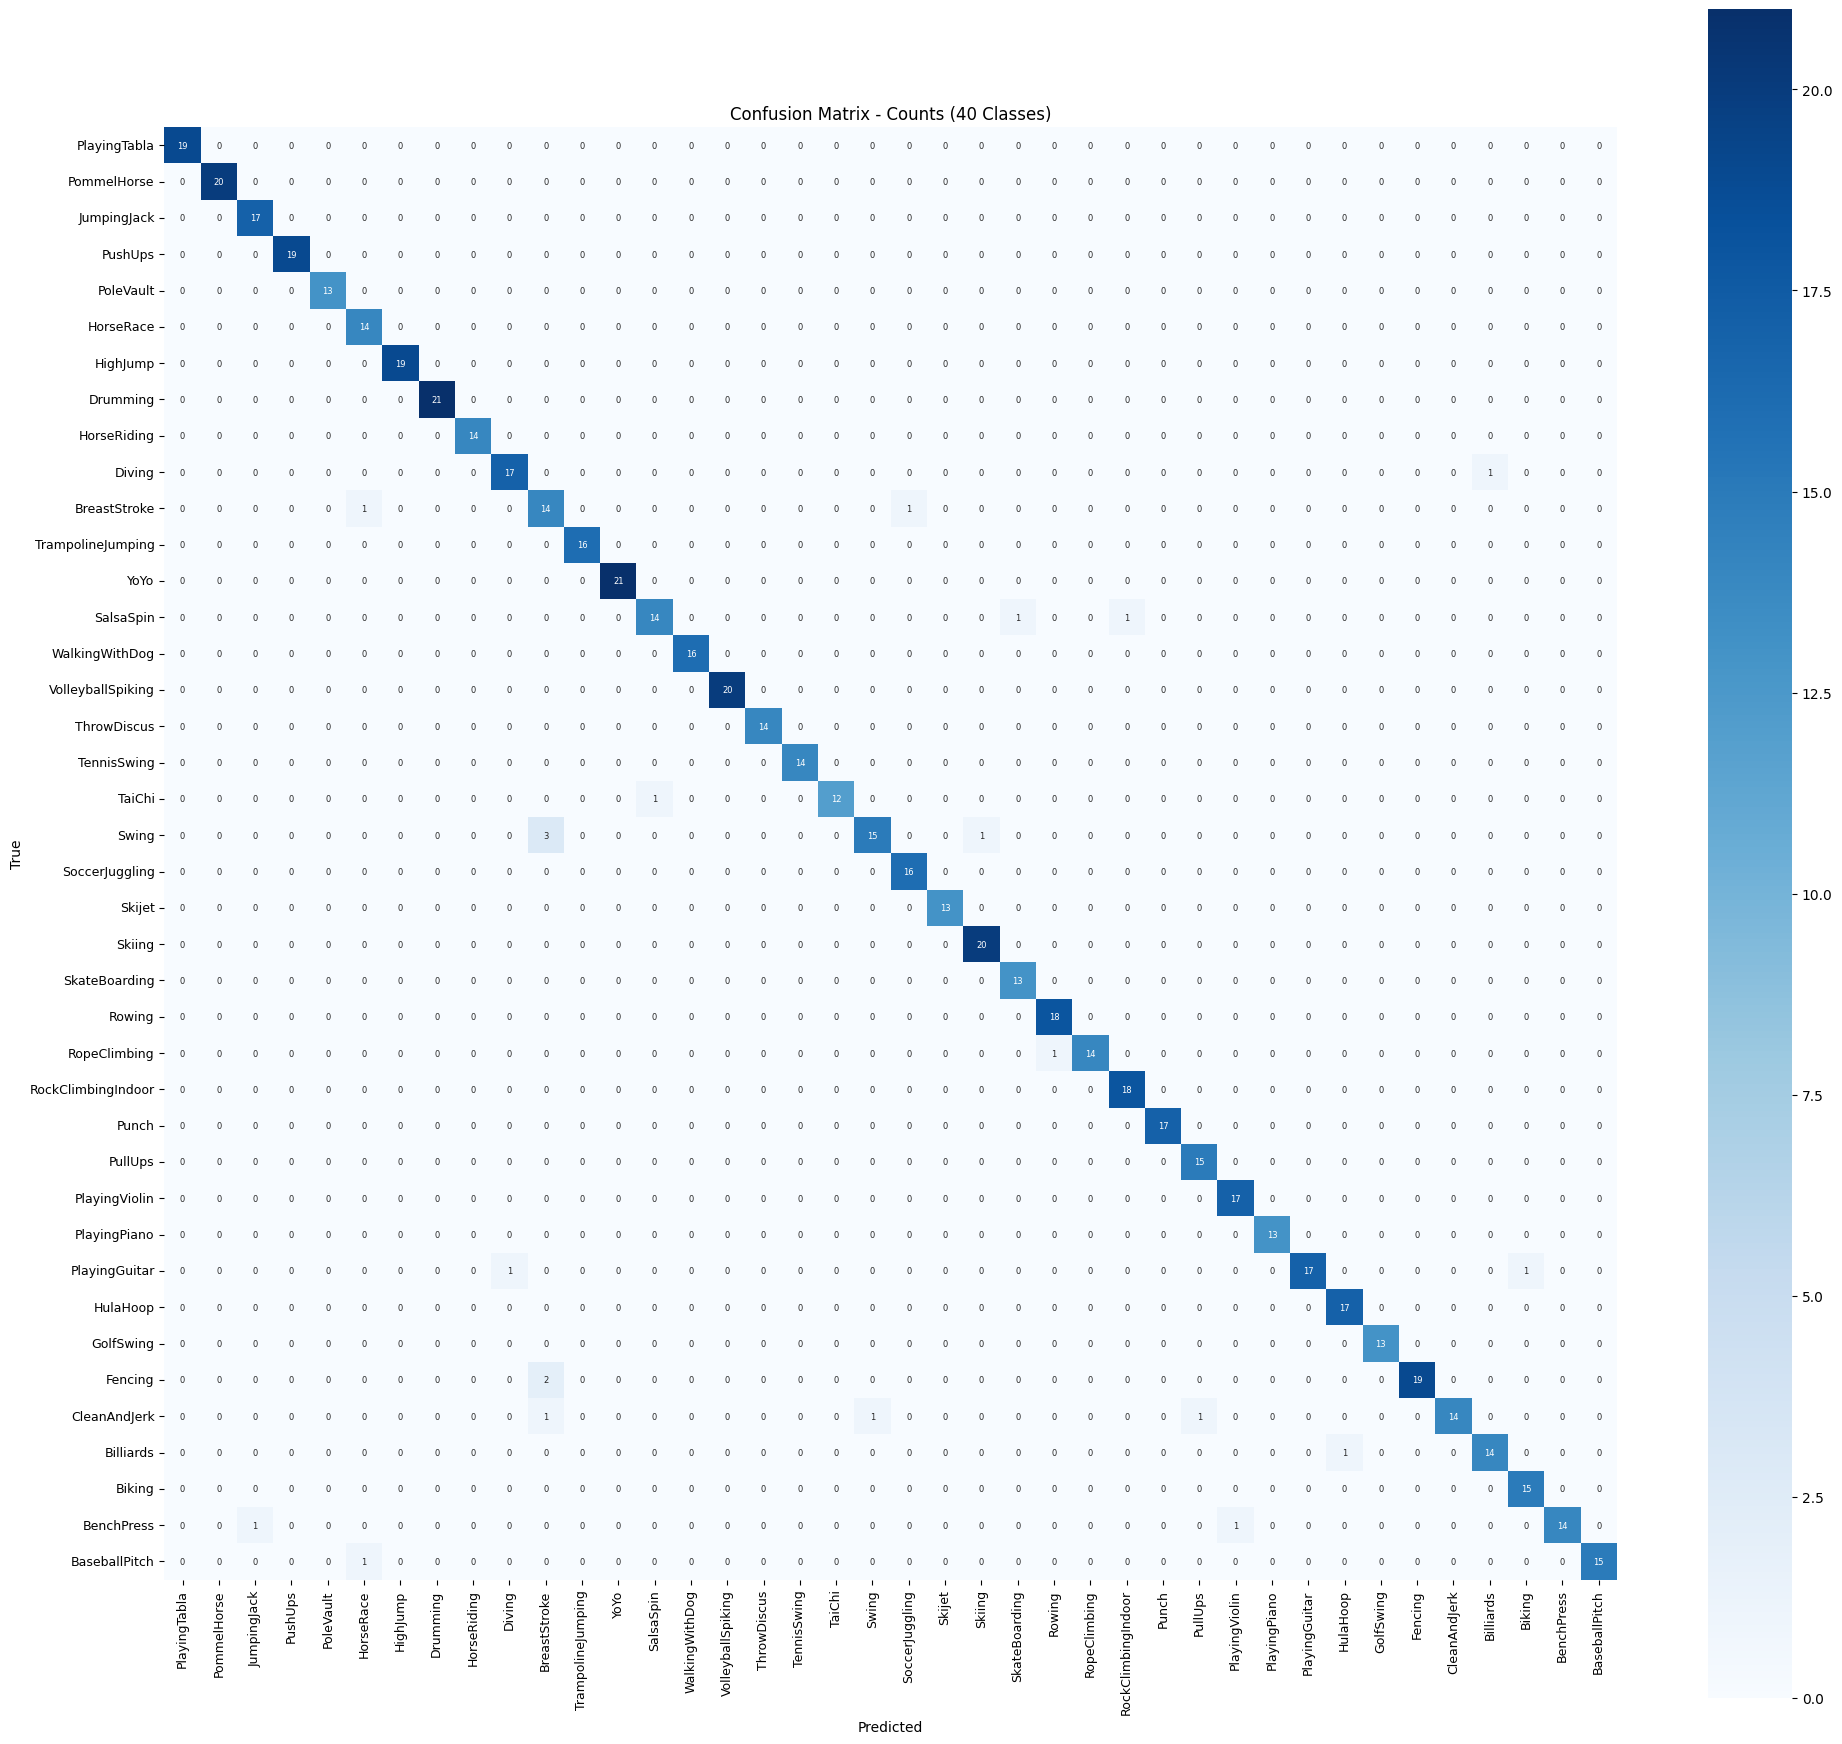

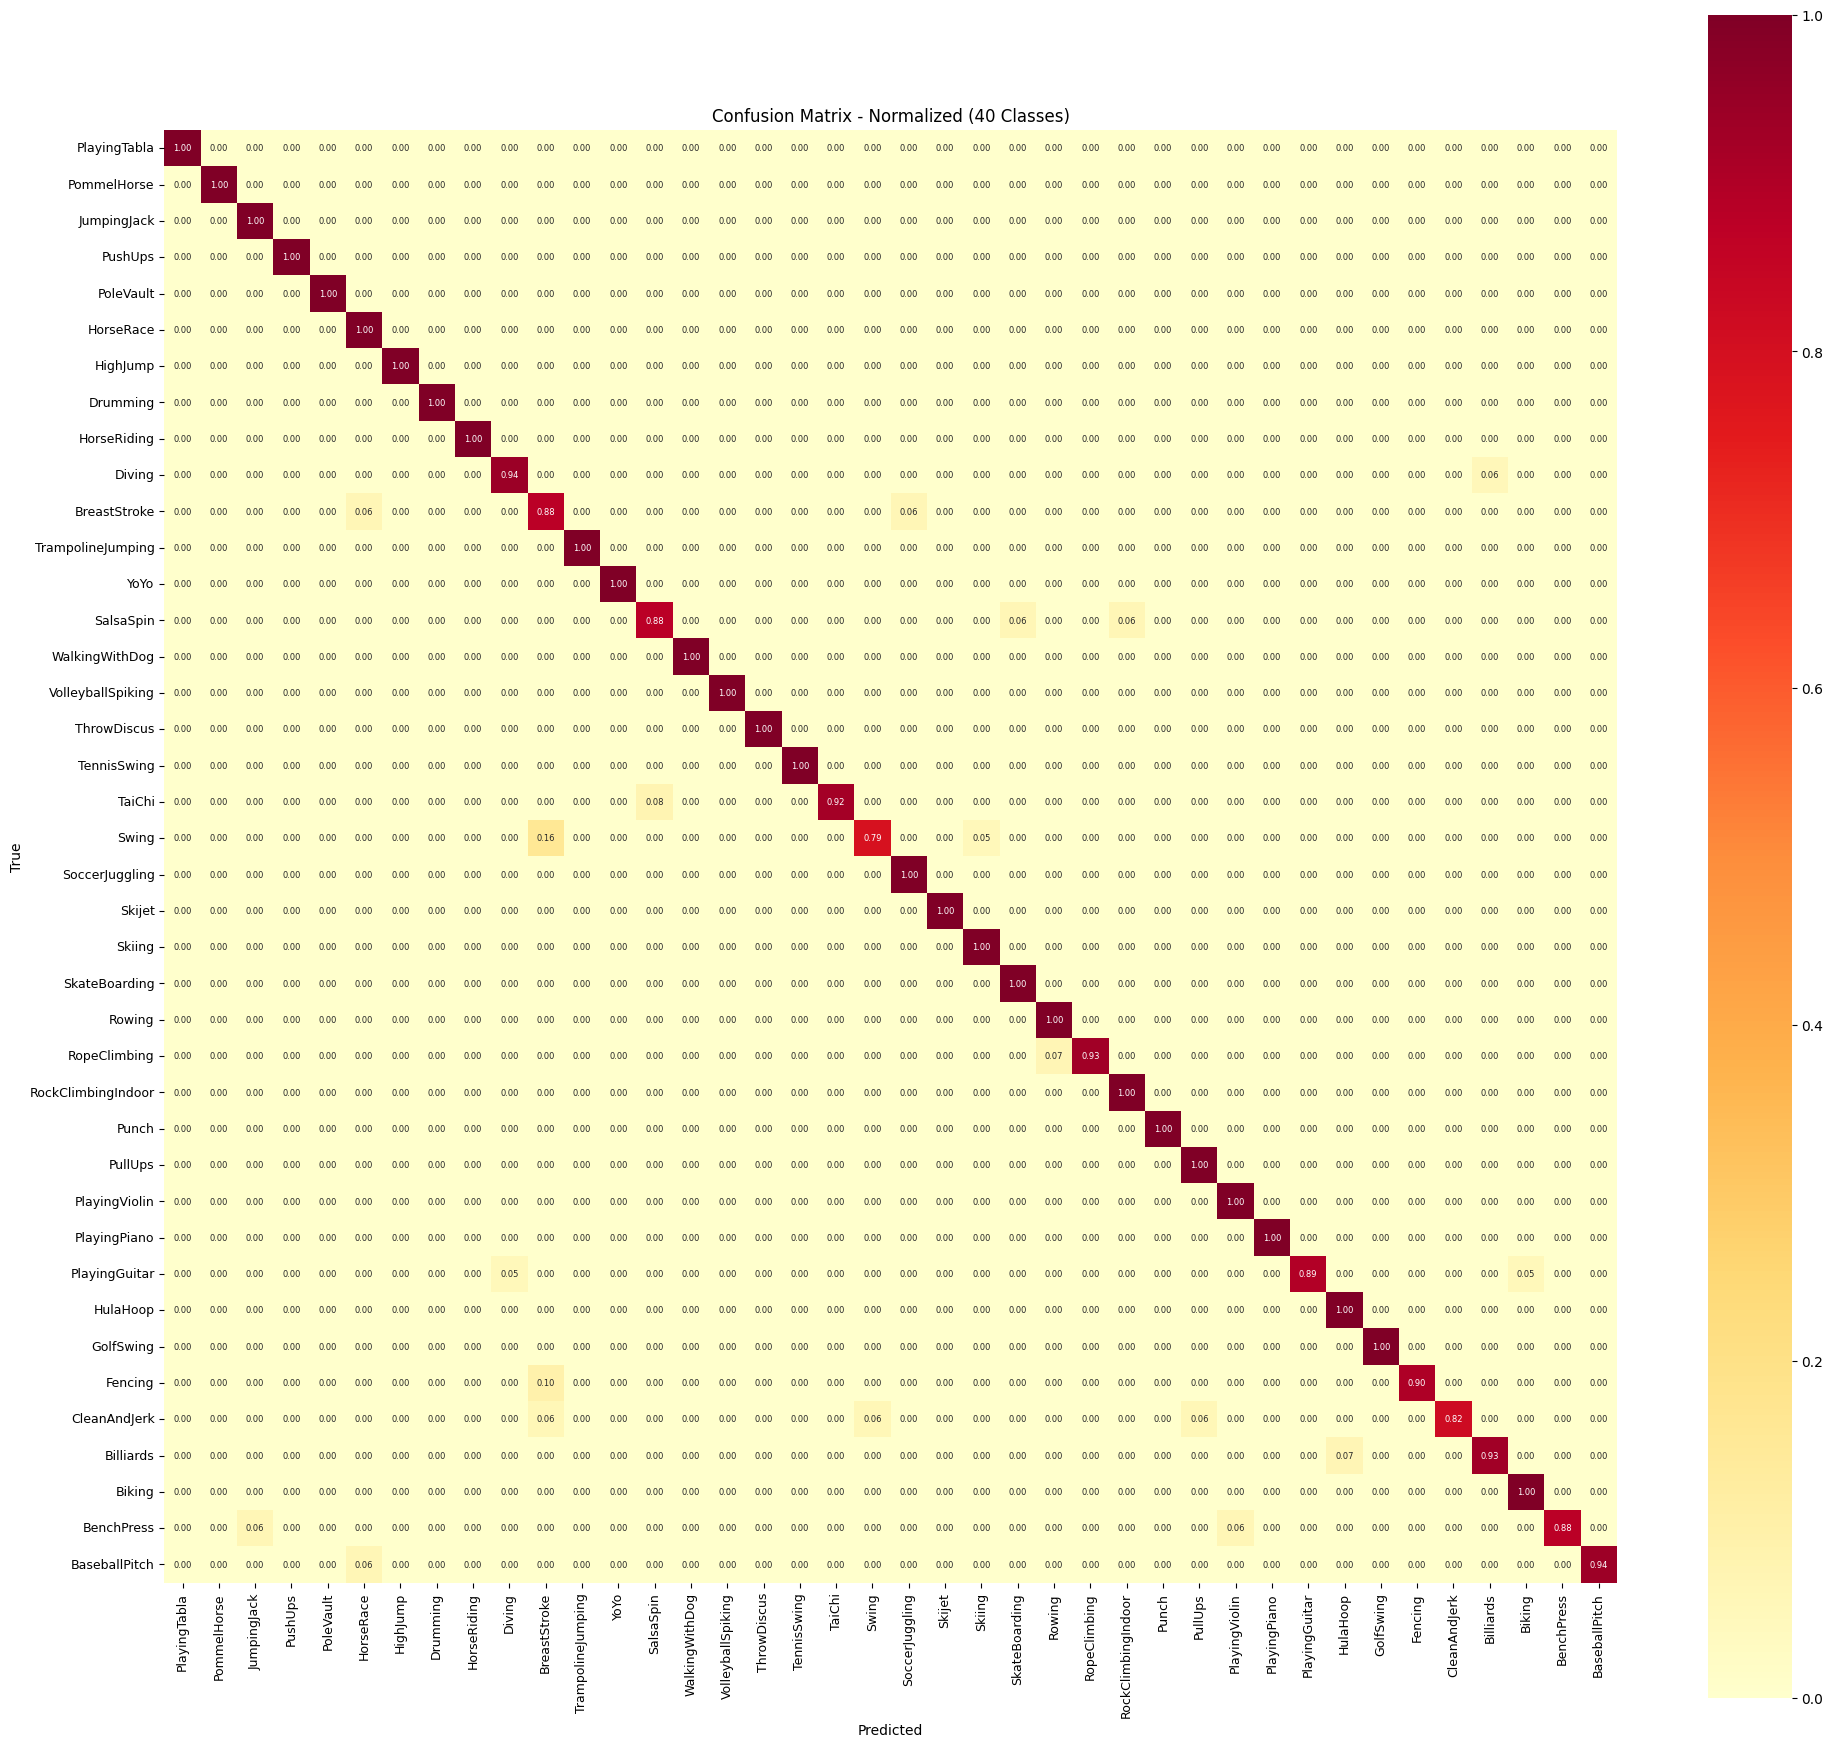

In [28]:
plot_confusion_matrix(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)

In [29]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)




METRICS (Weighted Average)


Accuracy:     0.9668
Precision:    0.9695
Recall:       0.9668
F1-Score:     0.9669



PER-CLASS METRICS


                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        19
       PommelHorse       1.00      1.00      1.00        20
       JumpingJack       0.94      1.00      0.97        17
           PushUps       1.00      1.00      1.00        19
         PoleVault       1.00      1.00      1.00        13
         HorseRace       0.88      1.00      0.93        14
          HighJump       1.00      1.00      1.00        19
          Drumming       1.00      1.00      1.00        21
       HorseRiding       1.00      1.00      1.00        14
            Diving       0.94      0.94      0.94        18
      BreastStroke       0.70      0.88      0.78        16
 TrampolineJumping       1.00      1.00      1.00        16
              YoYo       1.00      1.00      1.00        21
         SalsaSpin  

## **VGG19_BN + LSTM**

In [30]:
class VGG19BN_LSTM(nn.Module):
    def __init__(self, hidden_size=256, num_classes=len(SELECTED_CLASSES)):
        super(VGG19BN_LSTM, self).__init__()
        vgg = models.vgg19_bn(weights=VGG19_BN_Weights.DEFAULT)

        # Freeze all layers initially
        for param in vgg.features.parameters():
            param.requires_grad = False

        # Unfreeze last convolutional block
        for param in vgg.features[34:].parameters():
            param.requires_grad = True

        self.features = vgg.features

        self.lstm = nn.LSTM(input_size=512, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)

        # Remove torch.no_grad() to allow gradients through last conv layers
        features = self.features(x)         # [B*T, 512, 7, 7]
        features = features.mean([2,3])    # global average pooling -> [B*T, 512]
        features = features.view(batch_size, seq_len, -1)  # [B, T, 512]

        lstm_out, _ = self.lstm(features)
        output = self.fc(lstm_out[:, -1, :])
        return output

In [31]:
model = VGG19BN_LSTM().to(device)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:11<00:00, 48.2MB/s]


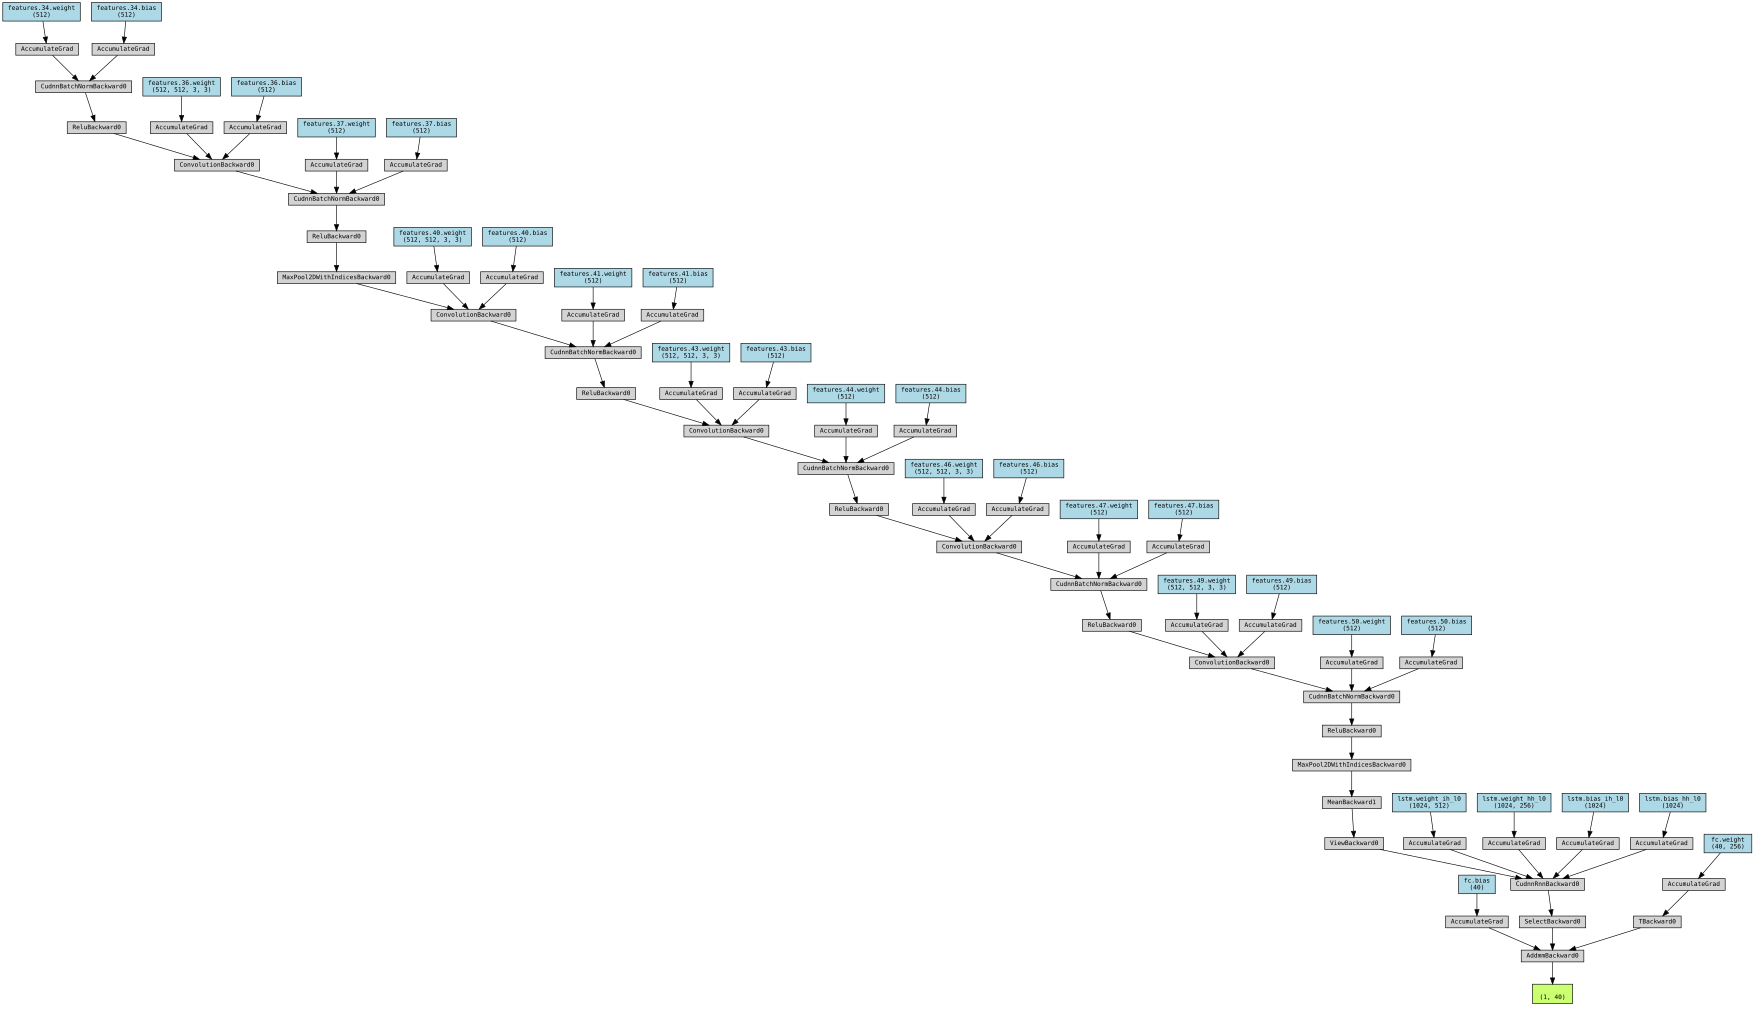

In [32]:
x = torch.randn(1, 16, 3, 224, 224).to(device)
y = model(x)

make_dot(y, params=dict(model.named_parameters()))

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [34]:
# fine-tune
results = fine_tune_model(model, train_loader, val_loader, criterion, optimizer,
                         num_epochs=10, save_flag=False)

Epoch [1/10] Train Loss: 2.2791 Acc: 0.4442 | Val Loss: 0.9677 Acc: 0.7876
Epoch [2/10] Train Loss: 0.9629 Acc: 0.7797 | Val Loss: 0.5265 Acc: 0.8651
Epoch [3/10] Train Loss: 0.5663 Acc: 0.8605 | Val Loss: 0.3351 Acc: 0.9116
Epoch [4/10] Train Loss: 0.3206 Acc: 0.9244 | Val Loss: 0.3020 Acc: 0.9256
Epoch [5/10] Train Loss: 0.2068 Acc: 0.9518 | Val Loss: 0.2504 Acc: 0.9271
Epoch [6/10] Train Loss: 0.1969 Acc: 0.9500 | Val Loss: 0.2777 Acc: 0.9225
Epoch [7/10] Train Loss: 0.1456 Acc: 0.9657 | Val Loss: 0.2421 Acc: 0.9287
Epoch [8/10] Train Loss: 0.1659 Acc: 0.9520 | Val Loss: 0.2394 Acc: 0.9302
Epoch [9/10] Train Loss: 0.1062 Acc: 0.9716 | Val Loss: 0.2736 Acc: 0.9240
Epoch [10/10] Train Loss: 0.1030 Acc: 0.9724 | Val Loss: 0.3019 Acc: 0.9209


In [35]:
# test the model
test_acc, all_preds, all_labels = test_model_with_predictions(model, test_loader, device=device)

Test Accuracy: 0.9231


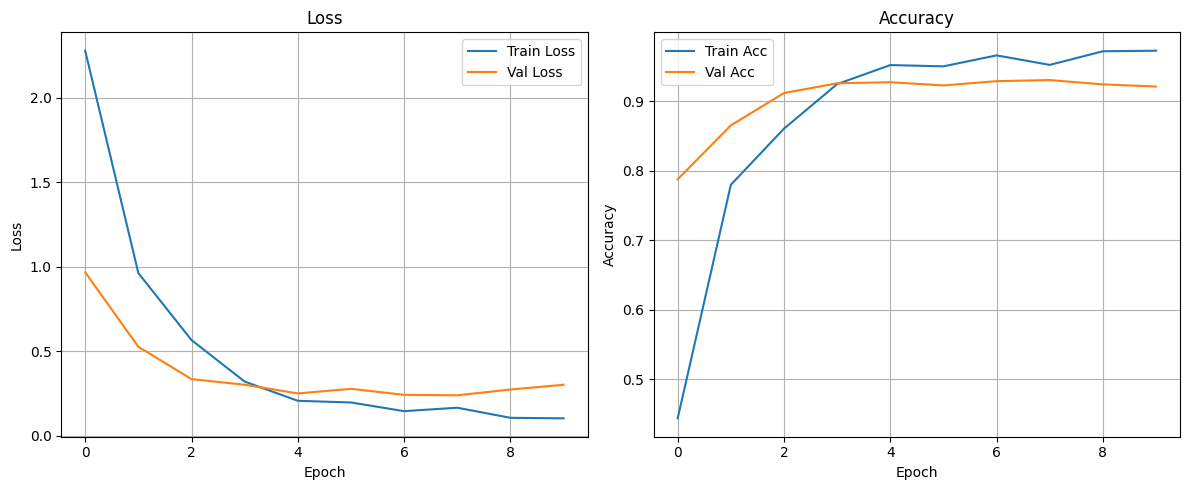

In [36]:
# plot results
plot_training_results(results)

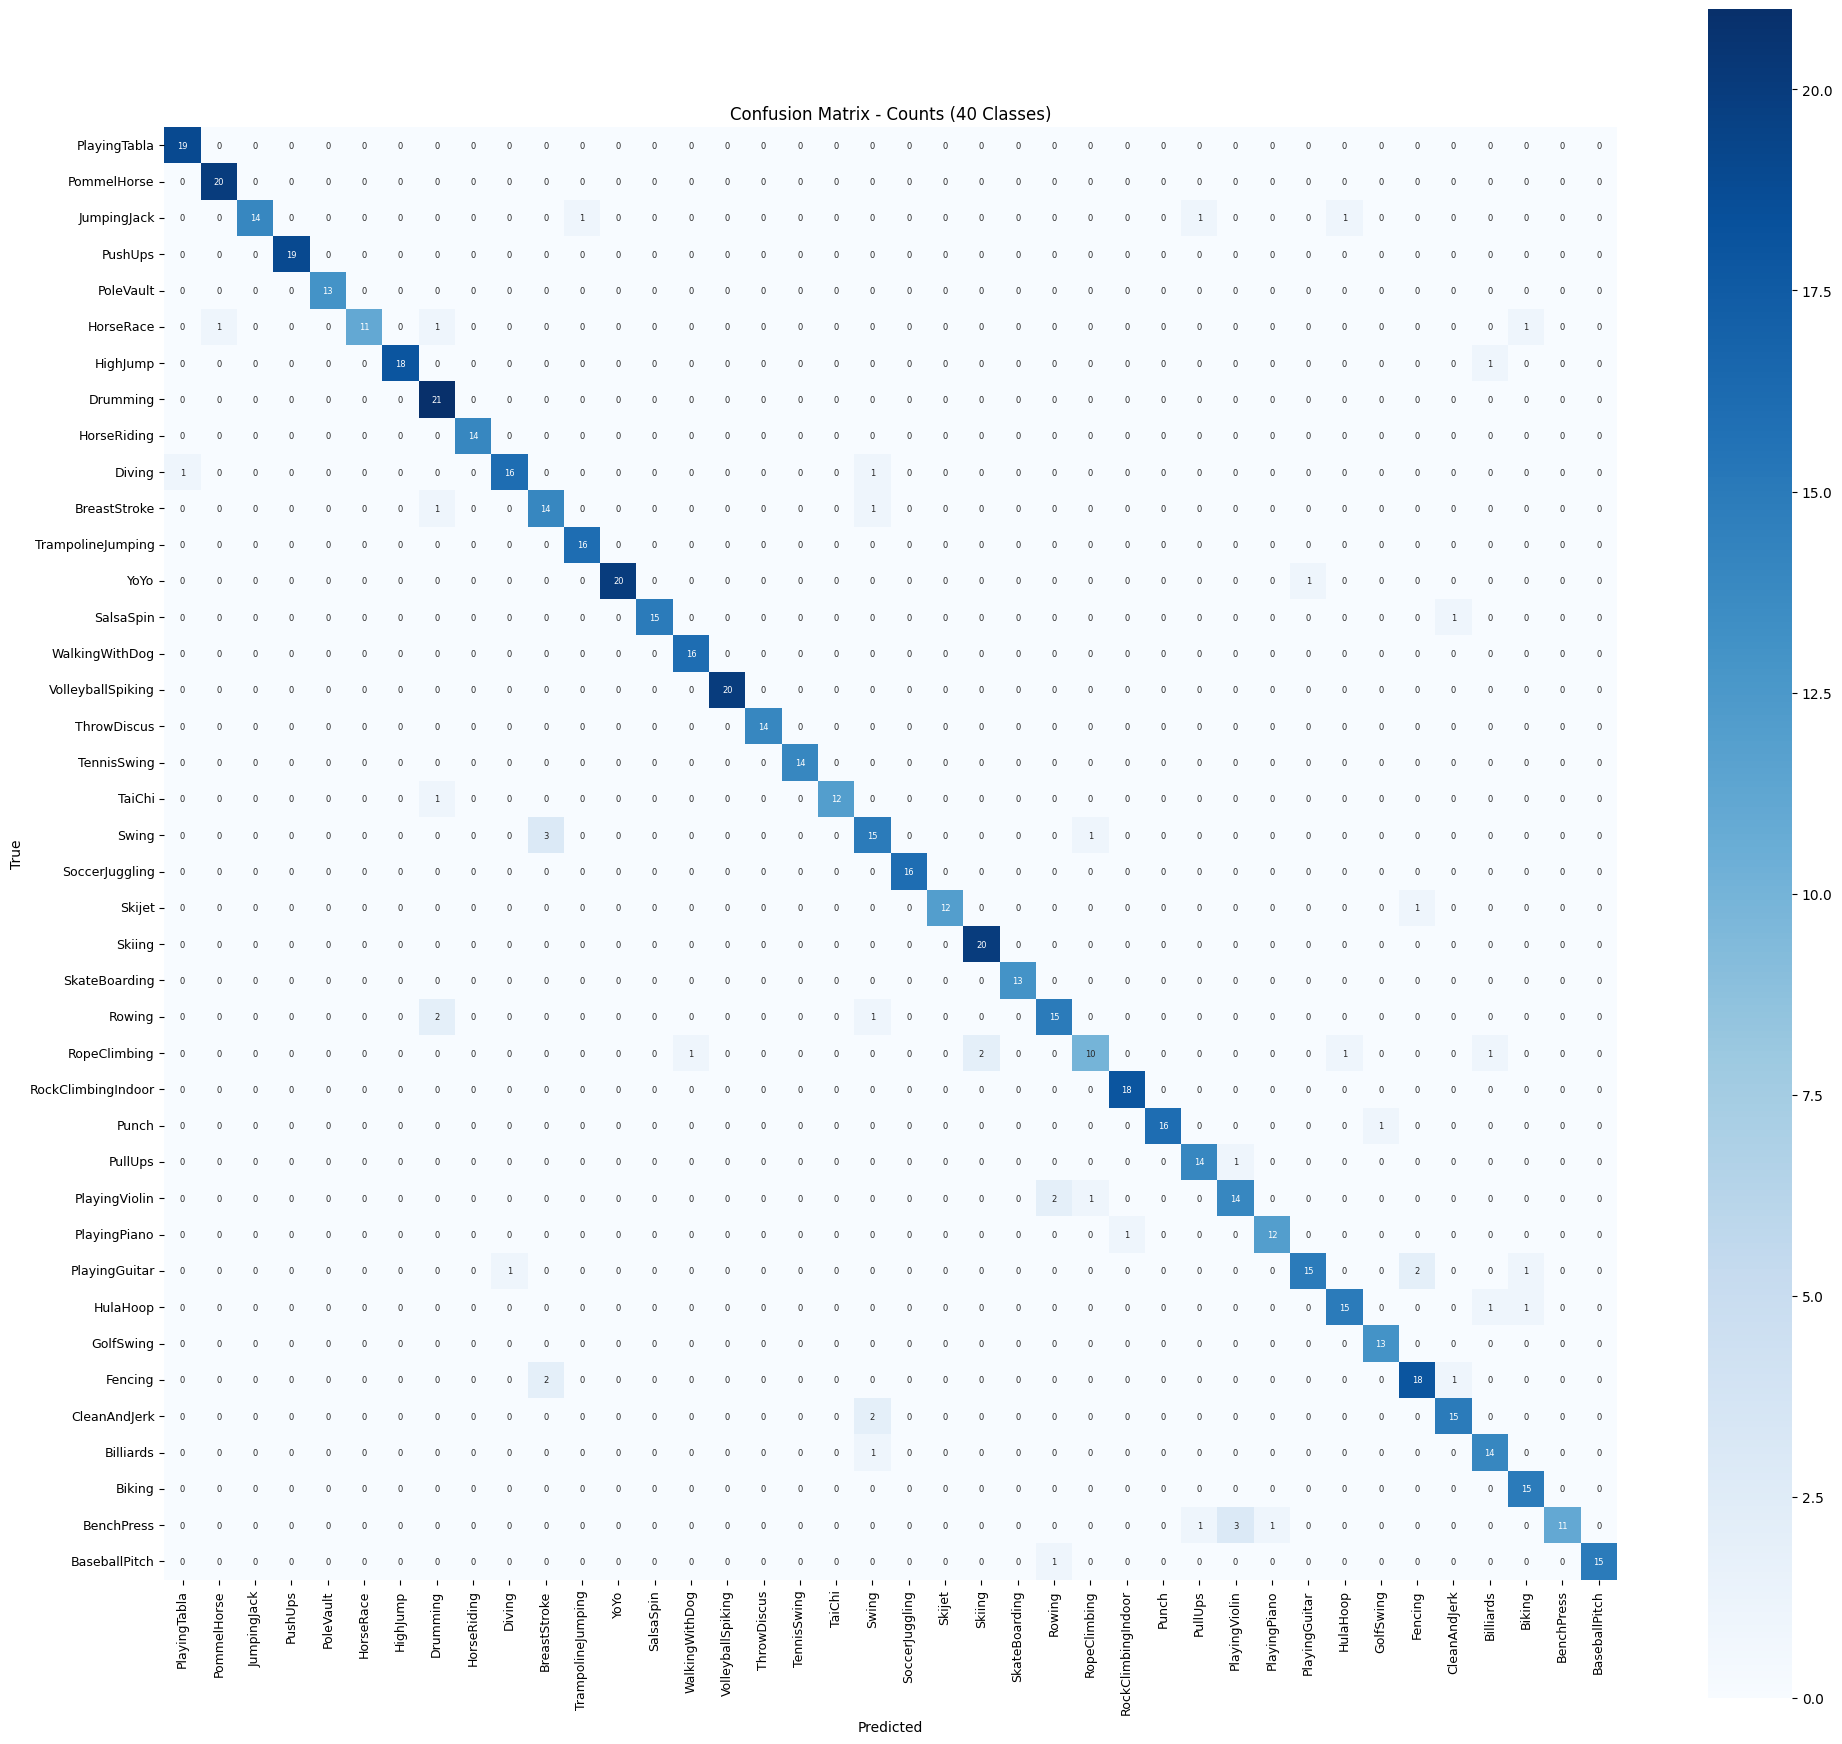

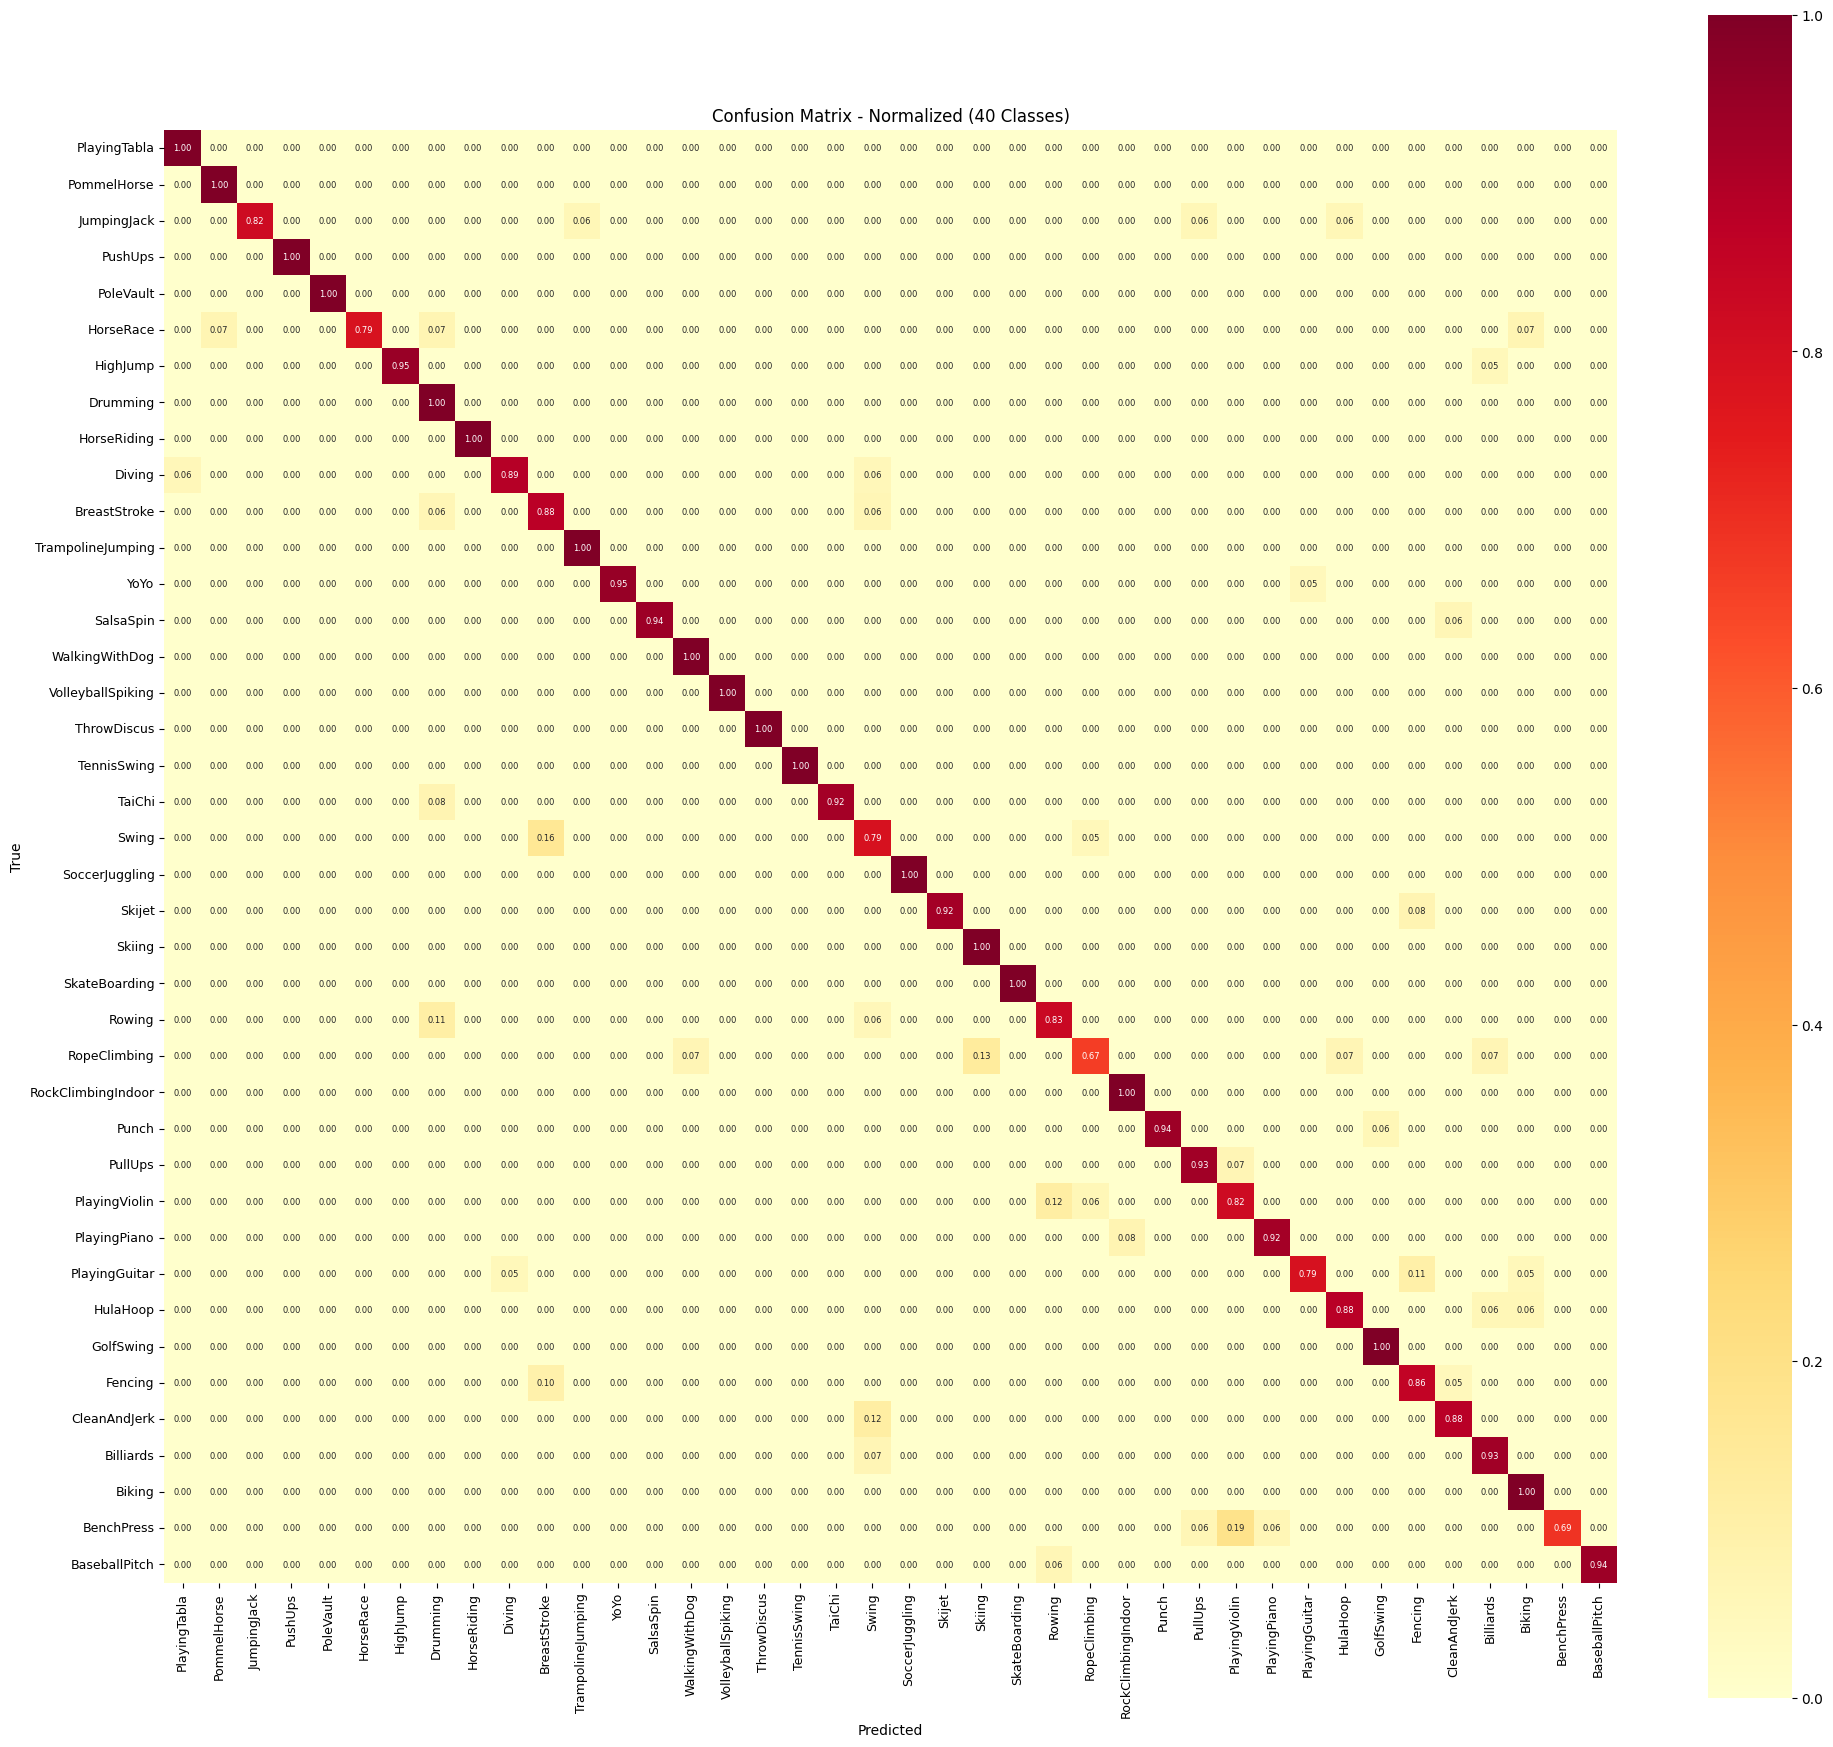

In [37]:
plot_confusion_matrix(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)

In [38]:
# print detailed metrics
print_detailed_metrics(all_labels, all_preds, num_classes=40, classes_list=CLASSES_LIST)




METRICS (Weighted Average)


Accuracy:     0.9231
Precision:    0.9281
Recall:       0.9231
F1-Score:     0.9228



PER-CLASS METRICS


                    precision    recall  f1-score   support

      PlayingTabla       0.95      1.00      0.97        19
       PommelHorse       0.95      1.00      0.98        20
       JumpingJack       1.00      0.82      0.90        17
           PushUps       1.00      1.00      1.00        19
         PoleVault       1.00      1.00      1.00        13
         HorseRace       1.00      0.79      0.88        14
          HighJump       1.00      0.95      0.97        19
          Drumming       0.81      1.00      0.89        21
       HorseRiding       1.00      1.00      1.00        14
            Diving       0.94      0.89      0.91        18
      BreastStroke       0.74      0.88      0.80        16
 TrampolineJumping       0.94      1.00      0.97        16
              YoYo       1.00      0.95      0.98        21
         SalsaSpin  

## **EXCTRACT FEATRES & SAVE**

In [ ]:
# take off classifier weights ('fc')
filtered_checkpoint = {k: v for k, v in checkpoint.items() if not k.startswith('fc.')}

# take only non-classifier layers
model_ResNet50.load_state_dict(filtered_checkpoint, strict=False)

model_ResNet50.eval()
model_ResNet50.to('cuda' if torch.cuda.is_available() else 'cpu')

ResNet50LSTM(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(

In [ ]:
# Paths for saving features
base_path = '/content/drive/MyDrive/apai/resnet50/features'
os.makedirs(base_path, exist_ok=True)

train_features_path = os.path.join(base_path, "train_features.pt")
train_labels_path   = os.path.join(base_path, "train_labels.pt")
val_features_path   = os.path.join(base_path, "val_features.pt")
val_labels_path     = os.path.join(base_path, "val_labels.pt")
test_features_path  = os.path.join(base_path, "test_features.pt")
test_labels_path    = os.path.join(base_path, "test_labels.pt")

print("Features will be saved in:", base_path)

def extract_features(model, clip_tensor):
    batch_size, seq_len, C, H, W = clip_tensor.shape
    clip_tensor = clip_tensor.to(device)
    with torch.no_grad():
        features = model.resnet(clip_tensor.view(batch_size * seq_len, C, H, W))
        features = features.view(batch_size, seq_len, -1)
        lstm_out, _ = model.lstm(features)
        video_features = lstm_out[:, -1, :]  # last timestep
    return video_features.cpu()

def process_dataloader(dataloader, model, features_file, labels_file):
    all_features = []
    all_labels = []
    for clips, labels in dataloader:
        features = extract_features(model, clips)
        all_features.append(features)
        all_labels.append(labels.cpu())
    all_features = torch.cat(all_features, dim=0)
    all_labels   = torch.cat(all_labels, dim=0)
    torch.save(all_features, features_file)
    torch.save(all_labels, labels_file)
    print(f"Saved features to {features_file}")
    print(f"Saved labels to {labels_file}")
    return all_features, all_labels

# exctract features for each train, val, test
train_features, train_labels = process_dataloader(train_loader, model, train_features_path, train_labels_path)
val_features, val_labels     = process_dataloader(val_loader, model, val_features_path, val_labels_path)
test_features, test_labels   = process_dataloader(test_loader, model, test_features_path, test_labels_path)

Features will be saved in: /content/drive/MyDrive/apai/resnet50/features
Saved features to /content/drive/MyDrive/apai/resnet50/features/train_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/train_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/val_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/val_labels.pt
Saved features to /content/drive/MyDrive/apai/resnet50/features/test_features.pt
Saved labels to /content/drive/MyDrive/apai/resnet50/features/test_labels.pt
